# Figure Making
Contains self-contained code to make most figures.

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import glob, torch, pickle, utils, model, copy
from tqdm import trange
import matplotlib as mpl
from scipy.optimize import curve_fit

%load_ext autoreload
%autoreload 2

# Some global settings
plt.rcParams['figure.dpi'] = 100
torch.set_grad_enabled(False)
mpl.rcParams['figure.figsize'] = [3.5, 2.5]

parser = utils.Args('1D Gabor')
parser.add('nonlinearity', 'relu')
parser.add('loss', 'MSE') # MSE or BCE

# model parameters
parser.add('N', 1000); parser.add('Nhid', 1000); parser.add('n_layers', 3)

# task parameters
parser.add('sig_w', 0.8); parser.add('sig_s', 0.2); parser.add('theta', np.pi)

# training parameter
parser.add('eta', 1e-4)
parser.add('n_learn', 2000000)
parser.add('n_train_trials', 500)
parser.add('n_test_trials', 10000) 
parser.add('test_interval', 500)
parser.add('noise_var', .01)

args = parser.parse_args()

stimuli = utils.GaborStimuli(args, simple_mode=False)
net = model.Model(args)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
calc_MLD(): MLD error is 0.15865647220940177


# Figure 1

## Input unit tuning curves

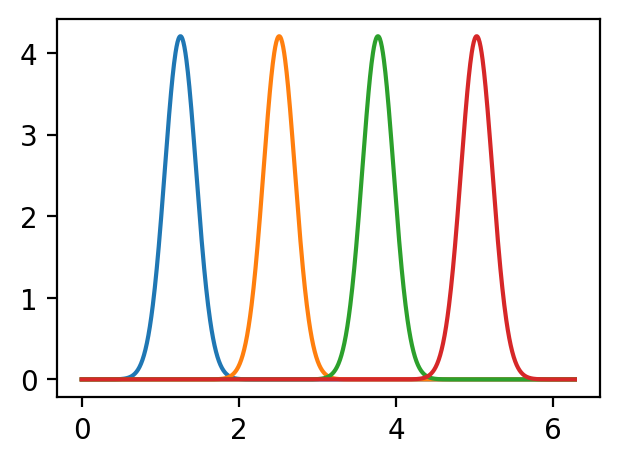

In [26]:
input_response_mat = np.zeros((1000, args.N))

angles = np.linspace(0, 2*np.pi, 1000, endpoint=False)

for i in range(len(angles)):
    input_response_mat[i] = utils.make_x0(angles[i], args.sig_s, 1000).flatten()
input_response_mat = torch.from_numpy(input_response_mat).float()

plt.figure()
plt.plot(angles, input_response_mat[200])
plt.plot(angles, input_response_mat[400])
plt.plot(angles, input_response_mat[600])
plt.plot(angles, input_response_mat[800])

# plt.savefig('figures/raw/input_tuning.svg')

## Tuning curve of cortical neurons
**Depends on the last cell for the `input_response_mat` variable**

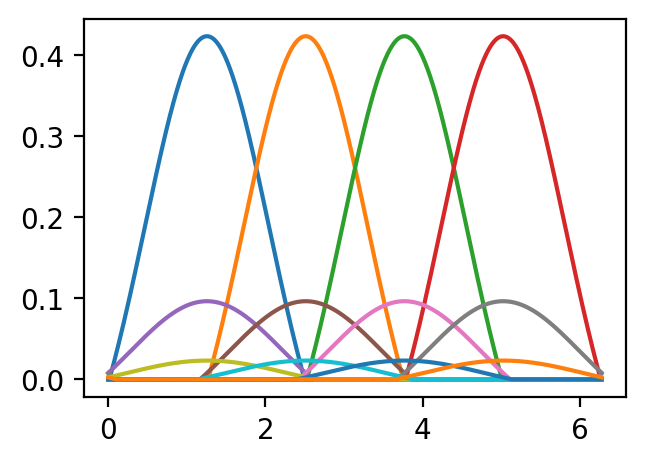

In [27]:
plt.figure()
layer1 = net.get_obs(input_response_mat, to_layer=1)
plt.plot(angles, layer1[200])
plt.plot(angles, layer1[400])
plt.plot(angles, layer1[600])
plt.plot(angles, layer1[800])

layer2 = net.get_obs(input_response_mat, to_layer=2)
plt.plot(angles, layer2[200])
plt.plot(angles, layer2[400])
plt.plot(angles, layer2[600])
plt.plot(angles, layer2[800])

layer3 = net.get_obs(input_response_mat, to_layer=3)
plt.plot(angles, layer3[200])
plt.plot(angles, layer3[400])
plt.plot(angles, layer3[600])
plt.plot(angles, layer3[800])

plt.savefig('figures/raw/tuning_cortical_neurons.svg')

# Figure 2

## 2A Information in the first layer

In [29]:
#%% FIG2 /// DATA /// sig_w to sig_s plot
# Note 07/24: using N=200 gets the same results as N=500

args2 = copy.copy(args)
args2.n_layers = 3
args2.N = 200
args2.Nhid = 200
args2.n_test_trials = 10000

sig_w_array = np.linspace(0.1, 1.5, 50)
sig_s_array = np.linspace(0.1, 1.5, 50)

mean_field_fi = np.zeros((len(sig_w_array), len(sig_s_array)))
fi = np.zeros_like(mean_field_fi)

for i in trange(len(sig_s_array)):
    args2.sig_s = sig_s_array[i]
    _stim = utils.GaborStimuli(args2, simple_mode=False, verbose=False)
    for j in range(len(sig_w_array)):
        args2.sig_w = sig_w_array[j]
        _net = model.Model(args2)
        mean_field_fi[i, j] = utils.get_mean_field_fi(_net, _stim, epsilon=1e-3)
        full_obs = _net.get_obs(_stim.te_stim()).numpy()
        obs1 = full_obs[:args2.n_test_trials]
        obs2 = full_obs[args2.n_test_trials:]
        cov1 = np.cov(obs1.T)
        cov2 = np.cov(obs2.T)
        mean_cov = (cov1 + cov2) / 2
        u, s, v = np.linalg.svd(mean_cov)
        sig = (obs1.mean(axis=0) - obs2.mean(axis=0)) / 2
        fi[i, j] = sig.reshape((1, -1)) @ np.linalg.inv(mean_cov + s[0] * 1e-3 * np.eye(args2.Nhid)) @ sig.reshape((-1, 1))


  2%|▏         | 1/50 [00:10<08:30, 10.43s/it]


KeyboardInterrupt: 

In [ ]:
plt.figure()
plt.scatter(mean_field_fi.flatten(), fi.flatten(), s=1)
# plt.savefig('figures/raw/fi_numerics_vs_theory.svg')
plt.figure()
plt.imshow(np.flip(fi, 0), extent=(0.1, 1.5, 0.1, 1.5), cmap='inferno', vmax=1)
plt.savefig('figures/raw/numerics_fi_3layers.svg')

## 2B,C Information decay over layers

In [139]:

#%% FIG2 /// DATA /// Information decay as a function of sig_w and depth
probe_args = copy.copy(args)
probe_args.n_layers = 3

sigma_pairs = [[0.2, 0.8], [1.2, 0.1]]

info_mat = np.ones((len(sigma_pairs), probe_args.n_layers + 1))
info_mat_linear = np.ones((len(sigma_pairs), probe_args.n_layers + 1))


def linear_fi(forward_mat, stimuli):
    slope = forward_mat @ stimuli.x1.t().numpy()
    covar = forward_mat @ forward_mat.T * stimuli.noise_var
    s = np.linalg.svd(covar, compute_uv=False, hermitian=True)
    return float(slope.T @ np.linalg.inv(covar + 1e-6 * s[0] * np.eye(covar.shape[0])) @ slope) 

for i in trange(len(sigma_pairs)):
    probe_args.sig_s, probe_args.sig_w = sigma_pairs[i]
    probe_stim = utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)
    fi0 = np.linalg.norm(probe_stim.x1.numpy())**2 / probe_args.noise_var
    probe_net = model.Model(probe_args)
    linear_forward_mat = probe_net.Ws[0]
    
    info_mat_linear[i, 1] = linear_fi(linear_forward_mat, probe_stim) / fi0

    for j in range(probe_args.n_layers):

        if j > 0:
            linear_forward_mat = probe_net.Ws[j] @ linear_forward_mat
            info_mat_linear[i, j + 1] = linear_fi(linear_forward_mat, probe_stim) / fi0

        info_mat[i, j + 1] = utils.get_mean_field_fi(probe_net, probe_stim, to_layer=j+1, epsilon=1e-6) / fi0


100%|██████████| 2/2 [00:00<00:00,  2.01it/s]


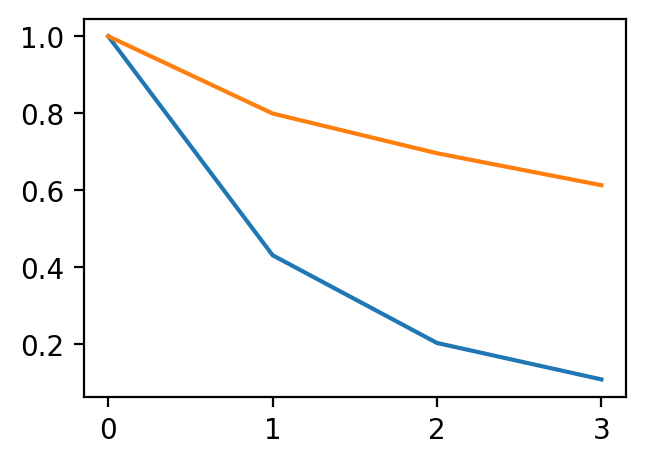

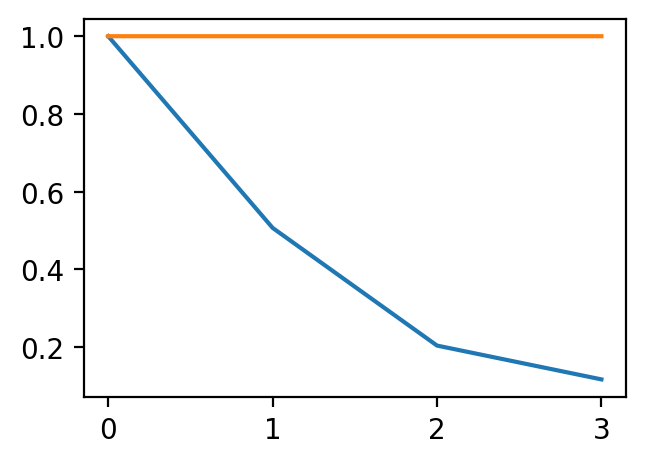

In [142]:
plt.figure()
plt.plot(info_mat.T)
plt.savefig('figures/raw/fi_over_layers.svg')

plt.figure()
plt.plot(info_mat_linear.T)
plt.savefig('figures/raw/fi_over_layers_linear_net.svg')

# Figure 3

## 3C Only train some matrices

In [ ]:
#%% FIG2 // PLOTTING // FREEZING EXPERIMENTS
'''Parameters: sigs=1.2, sigw=0.1'''
'''Raw results: sig_s=1.2, sig_w=0.2, noise_var=1, three layers, N=1000
Raw results are error percentages. Need to be converted to FI

baseline: 23.68; info: 0.514
Only freeze:
W1: 18.8 (info: 0.784)
W2: 15.9 (info: 1)
W3: 15.9 (info: 1)

Only train:
W1: 15.9 (info: 1)
W2: 18.8 (info: 0.784)
W3: 20.7 (info: 0.667)
'''

'''Raw results: sig_s=0.2, sig_w=0.8, noise_var=1, three layers, N=1000

baseline info: 0.0405
Only freeze:
W1: 41.9 (info: 0.459)
W2: 15.9 (info: 1)
W3: 15.9 (info: 1)

Only train:
W1: (info: 1)
W2:(info: 0.459)
W3:  (info: 0.149)
'''
plt.figure()
plt.bar(range(3), [1, 0.459, 0.149])

plt.bar(np.arange(3, 6), [.459, 1, 1])

plt.axhline(1, color='gray')
plt.axhline(0.04, color='gray')
plt.savefig('figures/only_train_or_freeze_one_layer.svg')

In [ ]:
#%% FIG 3 // DATA AND PLOTTING // W_EFF FIGURE
torch.set_grad_enabled(False)
args2 = copy.copy(args)
args2.sig_s = 1.2
args2.N = 500
args2.Nhid = 500
args2.n_test_trials = 50000
args2.n_layers=3
args2.sig_w = 0.1

stim2 = train_utils.GaborStimuli(args2)
net2 = model.Model(args2)

W_effs = r_utils.get_effective_weights(net2, stim2.x0)[0]

plt.figure()
plt.imshow(W_effs[2] @ W_effs[1] @ W_effs[0])
plt.savefig('figures/forward_mat_3layer_sigs1.2_sigw0.1.svg')

plt.figure()
plt.plot(stim2.x1.t())
plt.savefig('figures/x1_sigs1.2.svg')

#%% FIG 3 // DATA // V_EFF FIGURE
torch.set_grad_enabled(False)
args2 = copy.copy(args)
args2.sig_s = 1.2
args2.N = 300
args2.Nhid = 300
args2.n_test_trials = 50000
args2.n_layers=3
args2.sig_w = 0.1

sig_w_array = np.linspace(0.1, 1.5, 50)
sig_s_array = np.linspace(0.1, 1.5, 50)

angle_arr = np.zeros((len(sig_w_array), len(sig_s_array)))

v_eff_array = np.zeros((len(sig_w_array), len(sig_s_array), args2.N))

for i in trange(len(sig_s_array)):
    args2.sig_s = sig_s_array[i]
    _stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
    for j in range(len(sig_w_array)):
        args2.sig_w = sig_w_array[j]
        _net = model.Model(args2)
        Ws = r_utils.get_effective_weights(_net, _stim.x0)[0]
        forward_mat = Ws[2] @ Ws[1] @ Ws[0]
        # forward_mat = Ws[0]
        # _a = train_utils.mse_optimal_a(forward_mat, _stim, sing_val_truncation=1)
        covar = forward_mat @ forward_mat.T
        _u, _s, _v = np.linalg.svd(covar)
        _a = np.linalg.pinv(covar, rcond=_s[1]/_s[0]-0.01) @ forward_mat @ _stim.x1_normed.numpy().T
        v_eff = forward_mat.T @ _a
        v_eff_array[i, j] = v_eff.flatten()
        angle_arr[i, j] = utils.cos(v_eff, _stim.x1.numpy())

#%% FIG 3 // PLOTTING /// V_EFF FIGURE
fig = plt.figure()
plt.imshow(np.flip(angle_arr, 0), extent=(0.1, 1.5, 0.1, 1.5), aspect=1, cmap='inferno', vmin=0, vmax=1)
plt.ylabel('$\sigma_s$')
plt.xlabel('$\sigma_w$')
plt.colorbar()
plt.xticks([0.1, 0.5, 1.0, 1.5])
plt.yticks([0.1, 0.5, 1.0, 1.5])
plt.savefig('figures/sigs_sigw_three_layer_v_x1_angle.svg')

#%% FIG 3 // PLOTTING /// V_EFF FIGURE
args2.sig_s = 1.2
stim2 = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
plt.figure()
plt.plot(v_eff_array[39, 4])
plt.plot(stim2.x1_normed.t())
plt.savefig('figures/v_vs_x1_sigs1.2_sigw0.2.svg')
# plt.savefig('figures/v_vs_x1_sigs1.2_sigw1.2.svg')

# Figure 4

## 4A, error and percent changes of weights

## 4F L=1, compare delW norms between simulation and theory

In [42]:
#%% FIG 4 /// DATA /// One layer, Compare a and W norms

torch.set_grad_enabled(False)
args2 = copy.copy(args)
args2.sig_s = 0.2
args2.N = 1000
args2.Nhid = 1000
args2.n_test_trials = 50000
args2.n_layers=1
args2.sig_w = 0.8

name = '1L_MSE_GD_sigw_sigs0p2_etaP00001_'
utils.process_raw_data(name)
dataset = utils.find_and_load_data(name)
theory_results = pickle.load(open('Saved Results/theory_1L_sigs0P2', 'rb'))

# Compute dela / a and delw / w from theory

dela_over_a = []; delw_over_w = []

_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
for i in range(30):
    args2.sig_w = theory_results['sig_w'][i]
    _net = model.Model(args2)
    a = train_utils.mse_optimal_a(w1, _stim)
    dela_over_a.append(np.linalg.norm(theory_results['dela_list'][i]) /
                       np.linalg.norm(theory_results['a'][i]))
    delw_over_w.append(np.linalg.norm(theory_results['delw1'][i]) /
                       np.linalg.norm(np.linalg.norm(_net.Ws[0])))

# Compute dela / a and del w / w from simulation
sigw_data = []; dela_over_a_data = []; delw_over_w_data = []
_stim = train_utils.GaborStimuli(args2, simple_mode=True)
for _data in dataset:
    sigw_data.append(_data['args'].sig_w)
    args2.sig_w = _data['args'].sig_w
    _net = model.Model(args2)

    # detect whether no SGD occurred in the simulation
    if len(_data['loss']) == 1:
        dela_over_a_data.append(0)
        delw_over_w_data.append(0)
    else:
        dela_over_a_data.append(np.linalg.norm(_data['a'][-1] - _data['a'][0]) /
                                np.linalg.norm(_data['a'][0]))
        delw_over_w_data.append(np.linalg.norm(_data['delW'][0][-1]['s']) /
                                np.linalg.norm(_net.Ws[0]))


Number of entries: 10
#0     1L_MSE_GD_sigw_sigs0p2_etaP00001_

 Loaded dataset: *** 1L_MSE_GD_sigw_sigs0p2_etaP00001_ ***, 
 created 2020-09-06 10:09:11.714341 

#    |N    |L    |error  |DelW1  |#entries|     
0    |1000 |1    |0.1579 |0.0266 |23     |     
1    |1000 |1    |0.1591 |0.0441 |20     |     
2    |1000 |1    |0.1574 |0.0381 |10     |     
3    |1000 |1    |0.1587 |0.0068 |16     |     
4    |1000 |1    |0.1596 |0.0509 |14     |     
5    |1000 |1    |0.1566 |0.0452 |12     |     
6    |1000 |1    |0.1578 |0.0558 |18     |     
7    |1000 |1    |0.1602 |0.0522 |19     |     
8    |1000 |1    |0.1574 |0.0574 |17     |     
9    |1000 |1    |0.1594 |0.0551 |16     |     
calc_MLD(): MLD error is 0.15865647220940177


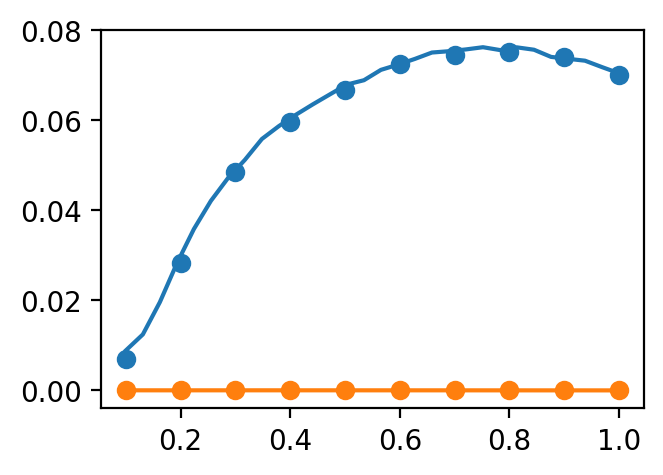

In [41]:
#%% FIG 4 /// PLOTTING /// One layer, Compare a and W norms
plt.figure()
plt.plot(theory_results['sig_w'], delw_over_w)
plt.scatter(sigw_data, delw_over_w_data)
plt.scatter(sigw_data, dela_over_a_data)
plt.plot(theory_results['sig_w'], dela_over_a)
plt.savefig('figures/raw/1L_delw_norm_and_dela.svg')

## 4B 4C L=1, compare simulated DelW and theory DelW

#0     1L_MSE_GD_sigw_sigs0p2_etaP00001_

 Loaded dataset: *** 1L_MSE_GD_sigw_sigs0p2_etaP00001_ ***, 
 created 2020-09-06 10:09:11.714341 

#    |N    |L    |error  |DelW1  |#entries|sig_w
0    |1000 |1    |0.1579 |0.0266 |23     |0.2  
1    |1000 |1    |0.1591 |0.0441 |20     |0.3  
2    |1000 |1    |0.1574 |0.0381 |10     |1.0  
3    |1000 |1    |0.1587 |0.0068 |16     |0.1  
4    |1000 |1    |0.1596 |0.0509 |14     |0.8  
5    |1000 |1    |0.1566 |0.0452 |12     |0.9  
6    |1000 |1    |0.1578 |0.0558 |18     |0.5  
7    |1000 |1    |0.1602 |0.0522 |19     |0.4  
8    |1000 |1    |0.1574 |0.0574 |17     |0.6  
9    |1000 |1    |0.1594 |0.0551 |16     |0.7  


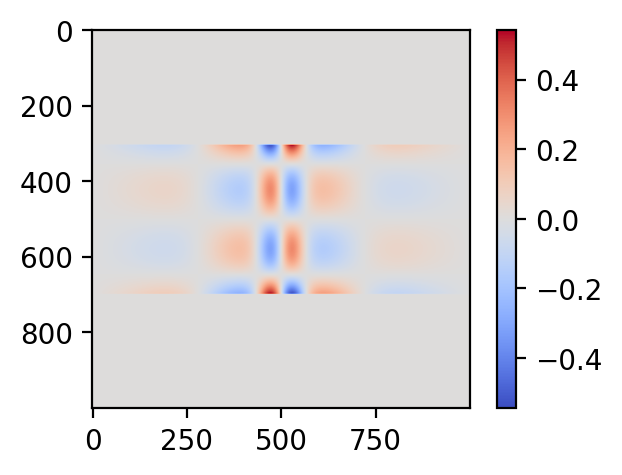

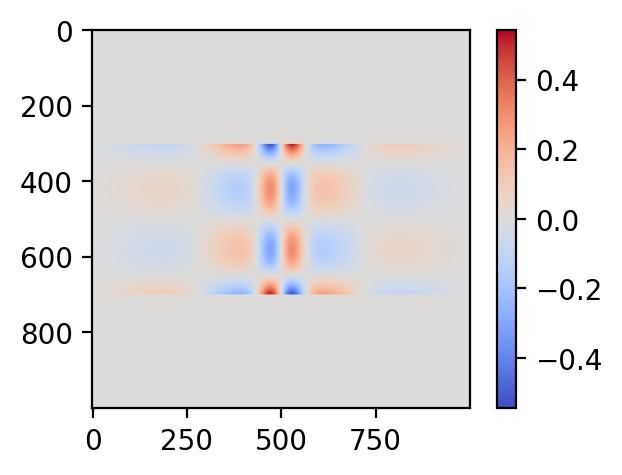

In [43]:
name = '1L_MSE_GD_sigw_sigs0p2_etaP00001_'
# utils.process_raw_data(name)
dataset = utils.find_and_load_data(name, 'sig_w')
theory_results = pickle.load(open('Saved Results/theory_1L_sigs0P2', 'rb'))

data_ind = 4
theory_ind = 23


args2 = copy.copy(args)
args2.sig_s = 0.2
args2.N = 1000
args2.Nhid = 1000
args2.n_test_trials = 50000
args2.n_layers=1
args2.sig_w = theory_results['sig_w'][theory_ind]
_net = model.Model(args2)

W_init = _net.Ws[0].copy()
t_utils.load_theory_changes(_net, [theory_results['delw1'][theory_ind]], theory_results['active_inds'][theory_ind])

#%% FIG 4 /// PLOTTING/// 1 Layer, compare delW

theory_diff = (_net.Ws[0] - W_init) * args2.N
vmin = theory_diff.min(); vmax = theory_diff.max()

plt.figure()
plt.imshow(utils.recover_matrix(dataset[data_ind]['delW'][0][-1]) * args2.N,
cmap='coolwarm', vmin=vmin, vmax=vmax)
plt.colorbar()
# plt.savefig('figures/raw/1layer_sgd_delW1_sigs0P2.svg')
plt.figure()
plt.imshow((_net.Ws[0] - W_init) * args2.N, 
cmap='coolwarm', vmin=vmin, vmax=vmax)
plt.colorbar()
# plt.savefig('figures/raw/1layer_theory_delW1_sigs0P2.svg')

## 4I L=3, compare delW norms

In [64]:
torch.set_grad_enabled(False)
args2 = copy.copy(args)
args2.sig_s = 0.2
args2.N = 1000
args2.Nhid = 1000
args2.n_test_trials = 50000
args2.n_layers=3
args2.sig_w = 0.8

dataset = utils.find_and_load_data('3Layers_SquaredError_GradDescent_sigw_sigs0p2__', 'sig_w')
theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))


# normalized changes from theory
delw1 = []; delw2 = []; delw3 = []

for i in range(30):
    args2.sig_w = theory_results['vary_values'][i]
    _net = model.Model(args2)
    delw1.append(np.linalg.norm(theory_results['delw1'][i]) /
                       np.linalg.norm(_net.Ws[0]))
    delw2.append(np.linalg.norm(theory_results['delw2'][i]) /
                       np.linalg.norm(_net.Ws[0]))
    delw3.append(np.linalg.norm(theory_results['delw3'][i]) /
                       np.linalg.norm(_net.Ws[0]))

# Compute dela / a and del w / w from simulation
delw1_data = []; delw2_data = []; delw3_data = []
sigw_data = []
for _data in dataset:
    sigw_data.append(_data['args'].sig_w)
    args2.sig_w = _data['args'].sig_w
    _net = model.Model(args2)

    delw1_data.append(np.linalg.norm(_data['delW'][0][-1]['s']) / np.linalg.norm(_net.Ws[0]))
    delw2_data.append(np.linalg.norm(_data['delW'][1][-1]['s']) / np.linalg.norm(_net.Ws[1]))
    delw3_data.append(np.linalg.norm(_data['delW'][2][-1]['s']) / np.linalg.norm(_net.Ws[2]))


#0    3Layers_SquaredError_GradDescent_sigw_sigs0p2__

 Loaded dataset: *** 3Layers_SquaredError_GradDescent_sigw_sigs0p2__ ***, 
 created 2020-08-21 14:44:15.642249 

#    |N    |L    |error  |DelW1  |#entries|sig_w
0    |1000 |3    |0.1602 |0.1105 |21     |0.2  
1    |1000 |3    |0.1590 |0.1946 |19     |0.3  
2    |1000 |3    |0.1585 |0.3310 |21     |1.0  
3    |1000 |3    |0.1572 |0.0379 |14     |0.1  
4    |1000 |3    |0.1590 |0.3604 |18     |0.8  
5    |1000 |3    |0.1567 |0.3507 |19     |0.9  
6    |1000 |3    |0.1594 |0.3056 |18     |0.5  
7    |1000 |3    |0.1593 |0.2571 |18     |0.4  
8    |1000 |3    |0.1587 |0.3391 |17     |0.6  
9    |1000 |3    |0.1587 |0.3577 |18     |0.7  


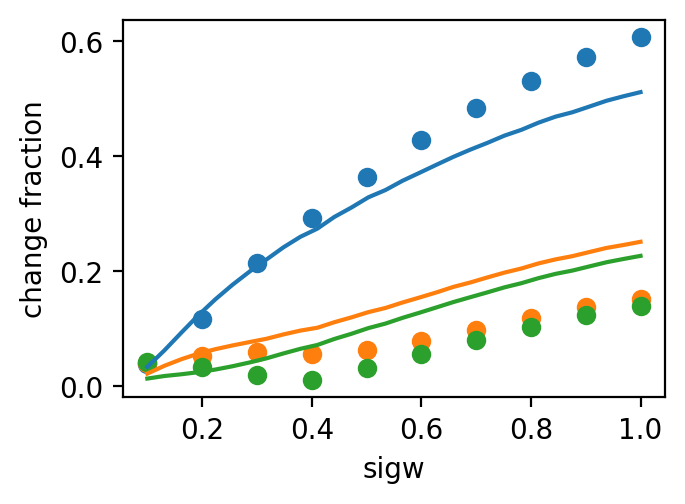

In [66]:
plt.figure()
plt.plot(theory_results['vary_values'], delw1)
plt.plot(theory_results['vary_values'], delw2)
plt.plot(theory_results['vary_values'], delw3)

plt.scatter(sigw_data, delw1_data)
plt.scatter(sigw_data, delw2_data)
plt.scatter(sigw_data, delw3_data)
plt.xlabel('sigw')
plt.ylabel('change fraction')
plt.savefig('figures/raw/l3_changes.svg')

## 5B L=3 Compare delW norms with L2 constraint

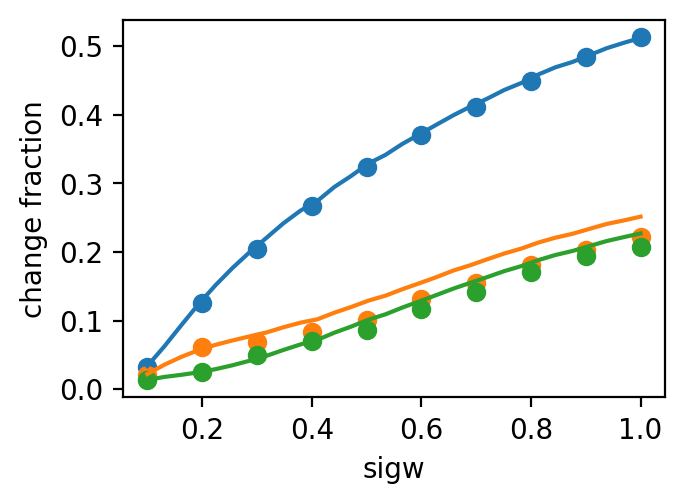

In [83]:
plt.figure()
plt.plot(theory_results['vary_values'], delw1)
plt.plot(theory_results['vary_values'], delw2)
plt.plot(theory_results['vary_values'], delw3)

plt.scatter(sigw_data, delw1_data)
plt.scatter(sigw_data, delw2_data)
plt.scatter(sigw_data, delw3_data)
plt.xlabel('sigw')
plt.ylabel('change fraction')
plt.savefig('figures/raw/l3_changes_with_l2.svg')

## Fig 5C Compare min-per solution in L=3 network, with or without freezing W2, W3

In [87]:
theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))

# normalized changes from theory
tot = []
args2 = copy.copy(args)
for i in range(30):
    args2.sig_w = theory_results['vary_values'][i]
    _net = model.Model(args2)
    delw1 = np.linalg.norm(theory_results['delw1'][i]) / np.linalg.norm(_net.Ws[0])
    delw2 = np.linalg.norm(theory_results['delw2'][i]) / np.linalg.norm(_net.Ws[1])
    delw3 = np.linalg.norm(theory_results['delw3'][i]) / np.linalg.norm(_net.Ws[2])
    
    tot.append(delw1 + delw2 + delw3)

delw_norm = np.zeros_like(theory_results['vary_values'])
probe_args = copy.copy(theory_results['args'])
stim = train_utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)

## Right singular vector of $\Delta W^1$
Compare right singular vectors from sgd, sgd+l2, theory

#0    3L_MSE_GD_sigw_sigsP2_lambdaP015_etaP001__

 Loaded dataset: *** 3L_MSE_GD_sigw_sigsP2_lambdaP015_etaP001__ ***, 
 created 2020-08-29 10:43:51.271533 

#    |N    |L    |error  |DelW1  |#entries|sig_w
0    |1000 |3    |0.1584 |0.1077 |164    |0.2  
1    |1000 |3    |0.1592 |0.1759 |164    |0.3  
2    |1000 |3    |0.1569 |0.2759 |163    |1.0  
3    |1000 |3    |0.1581 |0.0400 |163    |0.1  
4    |1000 |3    |0.1584 |0.2997 |164    |0.8  
5    |1000 |3    |0.1583 |0.2912 |164    |0.9  
6    |1000 |3    |0.1601 |0.2608 |164    |0.5  
7    |1000 |3    |0.1591 |0.2244 |164    |0.4  
8    |1000 |3    |0.1582 |0.2873 |163    |0.6  
9    |1000 |3    |0.1577 |0.2978 |163    |0.7  
#0    3L_MSE_GD_sigw_sigs0p2_etaP001_truesgd_

 Loaded dataset: *** 3L_MSE_GD_sigw_sigs0p2_etaP001_truesgd_ ***, 
 created 2020-09-17 09:21:34.928387 

#    |N    |L    |error  |DelW1  |#entries|sig_w
0    |1000 |3    |0.1579 |0.1315 |10     |0.2  
1    |1000 |3    |0.1598 |0.2199 |12     |0.3  
2    |1000 |3   

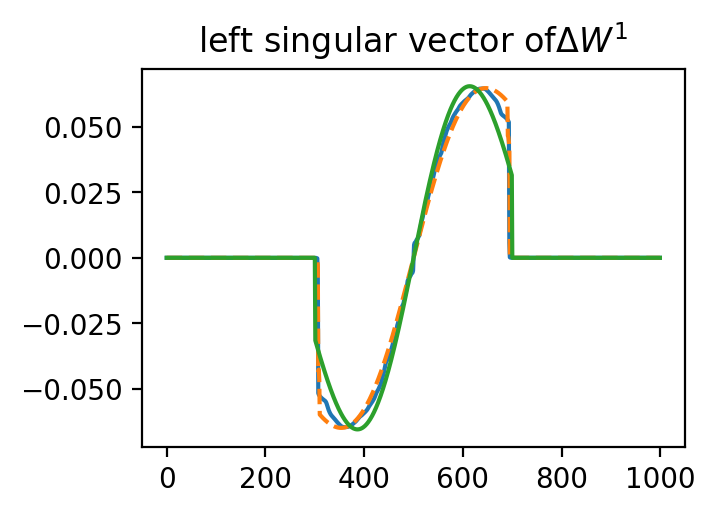

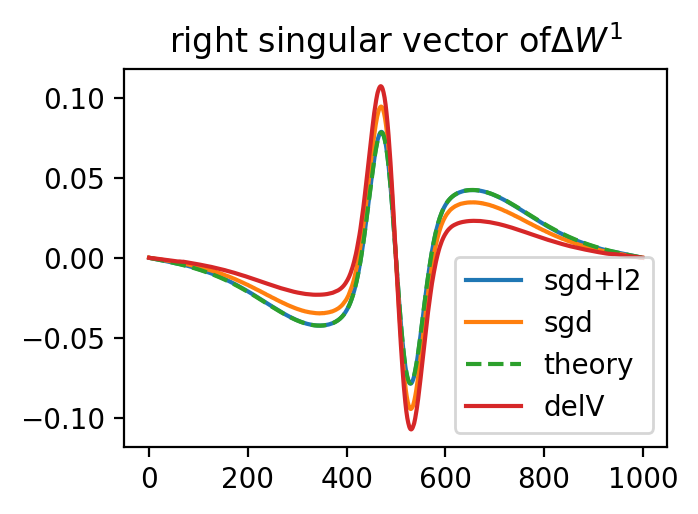

In [56]:
theory_ind = 23
data_ind = 4
layer_ind = 0

name = '3L_MSE_GD_sigw_sigsP2_lambdaP015_etaP001__'
dataset = utils.find_and_load_data(name, 'sig_w')

name2 = '3L_MSE_GD_sigw_sigs0p2_etaP001_truesgd_'
dataset2 = utils.find_and_load_data(name2, 'sig_w')

theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))

_net = model.Model(dataset[data_ind]['args'])
_stim = train_utils.GaborStimuli(dataset[data_ind]['args'], simple_mode=True, verbose=False)


full_delWs = r_utils.get_full_delw_mats([theory_results['delw1'][theory_ind],
                                        theory_results['delw2'][theory_ind],
                                        theory_results['delw3'][theory_ind]],
                                        theory_results['active_inds'][theory_ind],
                                        _net)

u, s, v = np.linalg.svd(full_delWs[layer_ind]) # decompose theory delW1

# normalized V_infty - V_0
del_veff = utils.normalize(dataset[data_ind]['v_eff'][-1] - dataset[data_ind]['v_eff'][0])

net = model.Model(dataset[data_ind]['args'])
a = dataset[data_ind]['a'][0].T

plt.figure()
plt.plot(dataset[data_ind]['delW'][layer_ind][-1]['u'][:, 0])
plt.plot(dataset2[data_ind]['delW'][layer_ind][-1]['u'][:, 0], ls='--')
plt.plot(u[:, 0] * -1)
# plt.plot(utils.normalize(a))
plt.title(f'left singular vector of$\Delta W^{layer_ind+1}$')
# plt.savefig('figures/raw/1_layer_delw1_left_vec_theory_vs_sim.svg')

plt.figure()
plt.plot(dataset[data_ind]['delW'][layer_ind][-1]['v'][0] * -1, label='sgd+l2')
plt.plot(dataset2[data_ind]['delW'][layer_ind][-1]['v'][0] * -1, label='sgd')
plt.plot(v[0, :], label='theory', ls='--')
plt.plot(del_veff * -1, label='delV')
plt.legend()
plt.title(f'right singular vector of$\Delta W^{layer_ind+1}$')
plt.savefig('figures/raw/3L_rightarrow_delw1.svg')

## Compare total delW norm across lambda2

#0     3L_MSE_GD_N_sigsP2_sigwP8_
#1     3L_MSE_GD_lambda_sigs0p2_sigw0p8_
#2     3L_MSE_GD_lambda_sigs0p2_sigw0p8_batch1000_
#3     3L_MSE_GD_lambda_sigs0p2_sigw0p8_etaP0001_
#4    3L_MSE_GD_lambda_sigs0p2_sigw0p8_etaP0003
#5    3L_MSE_GD_lambda_sigs0p2_sigw0p8_logscale_
#6    3L_MSE_GD_sigsP2_sigwP8_etap005_reps
#7    3L_MSE_GD_sigsP2_sigwP8_etap01_reps
#8    3L_MSE_GD_sigsP2_sigwP8_etap05_reps
#9    3L_MSE_GD_sigw_sigs0p2_etaP001_truesgd_
#10    3L_MSE_GD_sigw_sigs0p2_etaP005_truesgd_
#11    3L_MSE_GD_sigw_sigs0p2_etaP01_truesgd_
#12    3L_MSE_GD_sigw_sigs0p2_lambdaP005_
#13    3L_MSE_GD_sigw_sigs0p2_lambdaP010_
#14    3L_MSE_GD_sigw_sigs0p2_lambdaP010_N2000_
#15    3L_MSE_GD_sigw_sigs0p2_lambdaP010_etaP0001_
#16    3L_MSE_GD_sigw_sigs0p2_lambdaP015_
#17    3L_MSE_GD_sigw_sigs0p2_lambdaP015_N2000_
#18    3L_MSE_GD_sigw_sigs0p2_lambdaP015_batch1000_
#19    3L_MSE_GD_sigw_sigs0p2_lambdaP015_batch1000_etaP005_
#20    3L_MSE_GD_sigw_sigs0p2_lambdaP015_etaP0001_
#21    3L_MSE_GD_sigw_sig

Enter index of the .data object to load. 5



 Loaded dataset: *** 3L_MSE_GD_lambda_sigs0p2_sigw0p8_logscale_ ***, 
 created 2020-09-15 23:34:59.064161 

#    |N    |L    |error  |DelW1  |#entries|sig_w
0    |1000 |3    |0.1601 |0.3584 |441    |0.8  
1    |1000 |3    |0.3783 |0.0191 |347    |0.8  
2    |1000 |3    |0.1596 |0.3665 |449    |0.8  
3    |1000 |3    |0.2250 |0.1660 |417    |0.8  
4    |1000 |3    |0.3255 |0.0607 |322    |0.8  
5    |1000 |3    |0.1579 |0.3014 |289    |0.8  
6    |1000 |3    |0.1584 |0.2999 |309    |0.8  
7    |1000 |3    |0.1596 |0.2904 |459    |0.8  
8    |1000 |3    |0.1691 |0.2561 |427    |0.8  


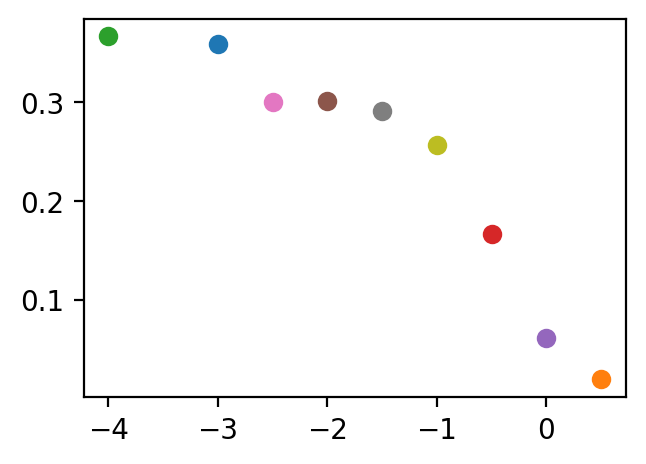

In [70]:
theory_ind = 23
data_ind = 4
layer_ind = 0

name = '3L_MSE_GD'
dataset = utils.find_and_load_data(name, 'sig_w')

plt.figure()
for entry in dataset:
    plt.scatter(np.log10(entry['args'].lambda2), np.linalg.norm(entry['delW'][0][-1]['s']))

In [ ]:


# plt.plot(a); plt.plot(dataset[data_ind]['a'][0])
#%% FIG4 // DATA and PLOTTING // Compare initial and final filters
args2 = copy.copy(args)
args2.sig_s = 0.2
args2.N = 1000
args2.Nhid = 1000
args2.n_test_trials = 50000
args2.n_layers=1
args2.sig_w = 0.8

theory_ind = 23
neuron_ind = 600
bl_net = model.Model(args2)
_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
filter0 = bl_net.Ws[0][neuron_ind].copy()

theory_results = pickle.load(open('Saved Results/theory_1L_sigs0P2', 'rb'))

t_utils.load_theory_changes(bl_net, [theory_results['delw1'][theory_ind]], theory_results['active_inds'][theory_ind])

filter_trained = bl_net.Ws[0][neuron_ind].copy()

plt.figure()
plt.plot(filter0 * args2.N, label='initial'); plt.plot(filter_trained * args2.N, label='final')
plt.plot(_stim.x1_normed.t() * np.sqrt(args2.N), label='optimal')
plt.axhline(0, color='k')
plt.savefig('figures/raw/compare_1layer_weights.svg')



#%% FIG5 // DATA and PLOTTING // Singular vector for DelW2 in 3-Layer, for both simulation and theory
name = '3L_MSE_GD_sigw_sigsP2_lambda0_etaP001__'
# utils.process_raw_data(name)
dataset = utils.find_and_load_data(name, attribute='sig_w')
data_sgd = dataset[4]

name = '3L_MSE_GD_sigw_sigsP2_lambdaP02_etaP001_long__'
# utils.process_raw_data(name)
dataset = utils.find_and_load_data(name, attribute='sig_w')
data_l2 = dataset[4]

args2 = copy.copy(args)
args2.sig_s = 0.2
args2.N = 1000
args2.Nhid = 1000
args2.n_test_trials = 50000
args2.n_layers=3
args2.sig_w = 0.8
_net = model.Model(args2)

theory_ind = 23  # index of theory results with the correct parameters 
layer_ind = 2

theory_results = pickle.load(open('Saved Results/THEORY_RESULTS_3_layers_sigs0p2', 'rb'))
full_delWs = r_utils.get_full_delw_mats([theory_results['delw1'][theory_ind], theory_results['delw2'][theory_ind],
                                         theory_results['delw3'][theory_ind]], theory_results['active_inds'][theory_ind], _net)
u, s, v = np.linalg.svd(full_delWs[layer_ind]) # decompose theory delW3


plt.figure()
plt.plot(data_sgd['delW'][layer_ind][-1]['u'][:, 0])
plt.plot(data_l2['delW'][layer_ind][-1]['u'][:, 0])
plt.plot(u[:, 0])
plt.savefig('figures/raw/3_layer_delw3_left_vec_theory_vs_sim.svg')

plt.figure()
plt.plot(data_sgd['delW'][layer_ind][-1]['v'][0])
plt.plot(data_l2['delW'][layer_ind][-1]['v'][0])
plt.plot(v[0] * -1)
plt.savefig('figures/raw/3_layer_delw1_right_vec_theory_vs_sim.svg')

#%% FIG5 // DATA and PLOTTING // Singular value ratios
name = '3L_MSE_GD_N_sigsP2_sigwP8_'
utils.process_raw_data(name)
dataset = utils.find_and_load_data(name, attribute='sig_w')


data_N = []
l1_ratios = []; l2_ratios = []; l3_ratios = []
for _data in dataset:
    data_N.append(_data['args'].N)
    l1_ratios.append(_data['delW'][0][-1]['s'][1] / _data['delW'][0][-1]['s'][0])
    l2_ratios.append(_data['delW'][1][-1]['s'][1] / _data['delW'][1][-1]['s'][0])
    l3_ratios.append(_data['delW'][2][-1]['s'][1] / _data['delW'][2][-1]['s'][0])

plt.figure()
plt.scatter(np.log(data_N), np.log(l1_ratios))
plt.scatter(np.log(data_N), np.log(l2_ratios))
plt.scatter(np.log(data_N), np.log(l3_ratios))

plt.xlim(4.2, 7.5)

plt.savefig('figures/raw/3layer_sing_val.svg')
#%% slope comparison
_net = model.Model(dataset[3]['args'])
_stim = train_utils.GaborStimuli(dataset[3]['args'])
W0 = r_utils.get_effective_weights(_net, _stim.x0, full_mat=True)[0][0]
_net.Ws[0] += utils.recover_matrix(dataset[3]['delW'][0][-1])
W1 = r_utils.get_effective_weights(_net, _stim.x0, full_mat=True)[0][0]

x10 = W0 @ _stim.x1.numpy().T / (1 / np.sqrt(dataset[3]['args'].N))
x11 = W1 @ _stim.x1.numpy().T / (1 / np.sqrt(dataset[3]['args'].N))
plt.figure()
plt.plot(x10)
plt.plot(x11 - x10)

plt.figure()
plt.scatter(dataset[3]['a'][-1] * np.sqrt(dataset[3]['args'].N), x11-x10, s=0.1)
plt.ylim(-0.04, 0.04)
plt.savefig('figures/del_slope_vs_a_one_layer.svg')


#%% FIG 5 /// DATA and PLOTTING /// SINGCOMP Compare delW singular vectors
sim_ind = 4
theory_ind = 23
layer_ind = 2


file_name = 'Saved Results/THEORY_RESULTS_3_layers_sigs0p2'

sig_w_arr = np.linspace(0.1, 1, 30)
theory_dict = pickle.load(open(file_name, 'rb'))

# load some simulation
file_name = '3L_MSE_GD_sigw_sigsP2_lambdaP015_etaP001_long__'
dataset = utils.find_and_load_data(file_name, attribute='sig_w')

_net = model.Model(dataset[sim_ind]['args'])
_stim = train_utils.GaborStimuli(dataset[sim_ind]['args'], simple_mode=True)

init_W = _net.Ws[layer_ind].copy()
t_utils.load_theory_changes(_net, [theory_dict['delw1'][theory_ind], theory_dict['delw2'][theory_ind], theory_dict['delw3'][theory_ind]], theory_dict['active_inds'][theory_ind])
theory_delW = _net.Ws[layer_ind] - init_W

u, s, v = np.linalg.svd(theory_delW)
plt.figure()
plt.plot(dataset[sim_ind]['delW'][layer_ind][-1]['u'][:, 0], label='sgd+l2')
plt.plot(u[:, 0], label='theory')


# load another simulation dataset
file_name = '3L_MSE_GD_sigw_sigsP2_lambda0_etaP001__'
dataset = utils.find_and_load_data(file_name, attribute='sig_w')
plt.plot(dataset[sim_ind]['delW'][layer_ind][-1]['u'][:, 0], label='sgd')
# plt.plot(_stim.x1_normed.t())
plt.legend()
plt.savefig('figures/raw/three_layer_delw3_left_vector.svg')


#%%
sig_w_array = theory_dict1['sig_w']
plt.figure()
plt.plot(sig_w_array, [np.linalg.norm(m) for m in delw1_list1])
plt.plot(sig_w_array, [np.linalg.norm(m) for m in delw1_list2])
plt.plot(sig_w_array, [np.linalg.norm(m) for m in delw1_list3])
plt.xlim(0.1, 0.6)
plt.savefig('figures/delw1_comparison.svg')

#%%
sig_w_array = theory_dict1['sig_w']
plt.figure()
plt.plot(sig_w_array, [np.linalg.norm(m) for m in delw2_list2])
plt.plot(sig_w_array, [np.linalg.norm(m) for m in delw2_list3])
plt.xlim(0.1, 0.6)
plt.savefig('figures/delw2_comparison.svg')

#%% analyze components of the right vector of W1

x1_comp1 = []; x1_comp2 = []; x1_comp3 = []
plt.figure()
for i in trange(29):
    x1_comp1.append(np.linalg.norm(delw1_list1[i] @ stimuli.x1_normed.numpy().T))
    x1_comp2.append(np.linalg.norm(delw1_list2[i] @ stimuli.x1_normed.numpy().T))
    x1_comp3.append(np.linalg.norm(delw1_list3[i] @ stimuli.x1_normed.numpy().T))

plt.figure()
plt.plot(sig_w_array[:29], x1_comp1)
plt.plot(sig_w_array[:29], x1_comp2)
plt.plot(sig_w_array[:29], x1_comp3)
#%% Calculate the initial order parameters
theta10_1l = np.zeros_like(sig_w_array)
theta20_1l = np.zeros_like(sig_w_array)
theta10_2l = np.zeros_like(sig_w_array)
theta20_2l = np.zeros_like(sig_w_array)
theta10_3l = np.zeros_like(sig_w_array)
theta20_3l = np.zeros_like(sig_w_array)


for i in trange(len(sig_w_array), position=0):
    args.sig_w = sig_w_array[i]
    args.sig_s = 1.2
    args.n_layers = 3
    net = model.Model(args)
    stimuli = train_utils.GaborStimuli(args, simple_mode=False, verbose=False)
    Ws = r_utils.get_effective_weights(net, stimuli.x0)[0]

    v_e = Ws[0].T @ Ws[1].T @ Ws[2].T @ a_list3[i]
    theta10_3l[i] = float(stimuli.x1_normed.numpy() @ v_e)
    v_eff.append(v_e)
    v_perp_raw = v_e - stimuli.x1_normed.numpy() @ v_e * stimuli.x1_normed.numpy().T
    theta20_3l[i] = np.linalg.norm(v_perp_raw)
    v_perp.append(v_perp_raw / np.linalg.norm(v_perp_raw))

    v_e = Ws[0].T @ Ws[1].T @ a_list2[i]
    theta10_2l[i] = float(stimuli.x1_normed.numpy() @ v_e)
    v_eff.append(v_e)
    v_perp_raw = v_e - stimuli.x1_normed.numpy() @ v_e * stimuli.x1_normed.numpy().T
    theta20_2l[i] = np.linalg.norm(v_perp_raw)
    v_perp.append(v_perp_raw / np.linalg.norm(v_perp_raw))

    v_e = Ws[0].T @  a_list1[i]
    theta10_1l[i] = float(stimuli.x1_normed.numpy() @ v_e)
    v_eff.append(v_e)
    v_perp_raw = v_e - stimuli.x1_normed.numpy() @ v_e * stimuli.x1_normed.numpy().T
    theta20_1l[i] = np.linalg.norm(v_perp_raw)
    v_perp.append(v_perp_raw / np.linalg.norm(v_perp_raw))

#%%
plt.figure()
plt.plot(sig_w_array[:28], theta10_1l[:28])
plt.plot(sig_w_array[:28], theta10_2l[:28])
plt.plot(sig_w_array[:28], theta10_3l[:28])
plt.xlabel('sig_w')
plt.ylabel('pre-PL theta1')
plt.savefig('figures/pre_pl_theta1.svg')

plt.figure()
plt.plot(sig_w_array[:28], theta20_1l[:28])
plt.plot(sig_w_array[:28], theta20_2l[:28])
plt.plot(sig_w_array[:28], theta20_3l[:28])
plt.xlabel('sig_w')
plt.ylabel('pre-PL theta2')
plt.savefig('figures/pre_pl_theta2.svg')

#%%
plt.figure()
plt.plot()
plt.plot(sig_w_array, np.sqrt((1 - theta10_1l)**2 + theta20_1l**2))
plt.plot(sig_w_array, np.sqrt((1 - theta10_2l)**2 + theta20_2l**2))
plt.plot(sig_w_array, np.sqrt((1 - theta10_3l)**2 + theta20_3l**2))

#%% FIG4 // DATA and PLOTTING // Singular values of DelW

plt.figure()
name = '3Layers_SquaredError_GradDescent_Standard_etaP0001_new__'
utils.process_raw_data(name)

dataset = utils.find_and_load_data(name, attribute='N')


data_N_list = []
data_sing_val_ratio_lists = [[] for i in range(dataset[0]['args'].n_layers)]

for _data in dataset:
    data_N_list.append(_data['args'].N)
    for i in range(dataset[0]['args'].n_layers):
        data_sing_val_ratio_lists[i].append(_data['delW'][i][-1]['s'][1] / _data['delW'][i][-1]['s'][0])

plt.figure()
for i in range(dataset[0]['args'].n_layers):
    plt.scatter(np.log10(data_N_list), np.log10(data_sing_val_ratio_lists[i]))
plt.xlabel('log10 N')
plt.ylabel('log10 sing val ratio')
# plt.savefig('figures/sing_vals_of_delw_3l.svg')

print(dataset[0]['args'].eta * np.linalg.norm(dataset[0]['a'][-1]))

#%% TEMP
plt.figure()
plt.imshow(utils.recover_matrix(dataset[0]['delW'][2][-1]))


# %% fIG4 // DATA and PLOTTING // Compare dela across layers
def get_a_ratio(dataset):
    output = []; sigw = []
    for _data in dataset:
        output.append(np.linalg.norm(_data['a'][-1] - _data['a'][0]) / np.linalg.norm(_data['a'][0]))
        sigw.append(_data['args'].sig_w)
    return np.sort(sigw), np.array(output)[np.argsort(sigw)]


plt.figure()
name = '2Layers_SquaredError_GradDescent_sigw_sigs0p2_'
dataset = utils.find_and_load_data(name, attribute='N')
sigw_arr, a_ratio_arr = get_a_ratio(dataset)
plt.plot(sigw_arr, a_ratio_arr)


#%% FIG5 // DATA // Compare three-layer theory with or without frozen W3
# Last editted: July 29, 2020

dict_3l_frozenW3 = pickle.load(open('THEORY_RESULTS_3_layers_frozenW3', 'rb'))
dict_3l = pickle.load(open('THEORY_RESULTS_3_layers', 'rb'))
dict_2l = pickle.load(open('THEORY_RESULTS_2_layers', 'rb'))

plt.figure()
plt.xlabel('sig_w'); plt.ylabel('||DelW||')
plt.plot(dict_3l_frozenW3['sig_w'][:28], [np.linalg.norm(m) for m in dict_3l_frozenW3['delw1'][:28]])
plt.plot(dict_3l['sig_w'][:28], [np.linalg.norm(m) for m in dict_3l['delw1'][:28]])
plt.title('delw1 norm')
plt.savefig('figures/delw1_3layers_freeze_or_not_freeze_w3.svg')

plt.figure()
plt.xlabel('sig_w'); plt.ylabel('||DelW||')
plt.plot(dict_3l_frozenW3['sig_w'][:28], [np.linalg.norm(m) for m in dict_3l_frozenW3['delw2'][:28]])
plt.plot(dict_3l['sig_w'][:28], [np.linalg.norm(m) for m in dict_3l['delw2'][:28]])
plt.title('delw2 norm')
plt.savefig('figures/delw2_3layers_freeze_or_not_freeze_w3.svg')

#%% FIG5 // DATA // Compare three-layer theory with or without frozen W3 (singular vectors)
args.n_layers = 3; args.sig_w = 0.1; args.sig_s = 1.2
bl_net = model.Model(args)
bl_stim = train_utils.GaborStimuli(args, simple_mode=True, verbose=False)
bl_Ws = r_utils.get_effective_weights(bl_net, bl_stim.x0)[0]

w1_left = (dict_3l['delw2'][0] + bl_Ws[1]).T @ (dict_3l['delw3'][0] + bl_Ws[2]).T @ dict_3l['a'][0]
w1_left_fr = (dict_3l_frozenW3['delw2'][0] + bl_Ws[1]).T @ (bl_Ws[2]).T @ dict_3l['a'][0]

plt.figure()
plt.plot(w1_left.flatten())
plt.plot(w1_left_fr.flatten())



#%% Fig 6 // DATA and PLOT // Slope figures
"""
Compare slope at the trained angle for naive and trained populations.
"""
ind = 23
sig_w_array = np.linspace(0.1, 1, 30)
args2 = copy.copy(args)
args2.n_layers = 3
args2.sig_w = sig_w_array[ind]
args2.sig_s = 0.2

args2.n_layers = 1
net1 = model.Model(args2)
args2.n_layers = 2
net2 = model.Model(args2)
args2.n_layers = 3
net3 = model.Model(args2)

stim = train_utils.GaborStimuli(args2, verbose=False, simple_mode=True)

def get_mean_slope(network, stimulus, to_layer):
    assert to_layer <= network.n_layers
    w_effs = r_utils.get_effective_weights(network, stimulus.x0)[0]
    if to_layer == 3:
        F = w_effs[2] @ w_effs[1] @ w_effs[0]
    elif to_layer == 2:
        F = w_effs[1] @ w_effs[0]
    elif to_layer == 1:
        F = w_effs[0]
    slope = np.abs(F @ stimulus.x1.numpy().T)
    return np.mean(slope)

slope1_1 = get_mean_slope(net1, stim, to_layer=1)
slope1_2 = get_mean_slope(net2, stim, to_layer=1)
slope1_3 = get_mean_slope(net3, stim, to_layer=1)
slope2_2 = get_mean_slope(net2, stim, to_layer=2)
slope2_3 = get_mean_slope(net3, stim, to_layer=2)
slope3_3 = get_mean_slope(net3, stim, to_layer=3)

t_utils.load_theory_changes(net1, [delw1_list1[ind]], active_inds_list1[ind])
t_utils.load_theory_changes(net2, [delw1_list2[ind], delw2_list2[ind]], active_inds_list2[ind])
t_utils.load_theory_changes(net3, [delw1_list3[ind], delw2_list3[ind], delw3_list3[ind]], active_inds_list3[ind])

# trained slope
slope1_1_tr = get_mean_slope(net1, stim, to_layer=1)
slope1_2_tr = get_mean_slope(net2, stim, to_layer=1)
slope1_3_tr = get_mean_slope(net3, stim, to_layer=1)
slope2_2_tr = get_mean_slope(net2, stim, to_layer=2)
slope2_3_tr = get_mean_slope(net3, stim, to_layer=2)
slope3_3_tr = get_mean_slope(net3, stim, to_layer=3)

plt.figure()
plt.bar([0, 0.5, 0.8, 1.3, 1.6, 1.9], [slope1_1_tr / slope1_1, slope1_2_tr / slope1_2, slope2_2_tr / slope2_2, slope1_3_tr / slope1_3,
                                       slope2_3_tr / slope2_3, slope3_3_tr / slope3_3], width=0.25)
plt.axhline(1)
plt.savefig('figures/raw/slope_ratio.svg')

#%% FIG 7 // Data and plot // Transfer across layers
args2 = copy.copy(args)
args2.n_layers = 3
args2.sig_s = 0.2
args.sig_w = 0.8

def convert_to_specificity(fi_array, baseline_fi):
    return (fi_array - baseline_fi) / (np.max(fi_array - baseline_fi))

stim = train_utils.GaborStimuli(args2, verbose=False, simple_mode=True)
probe_angles = np.linspace(np.pi, 1.5*np.pi, 32, endpoint=False)

linear_fi_array = np.zeros((3, len(probe_angles)))

baseline_linear_fi_array = np.zeros_like(linear_fi_array)

probe_args = copy.copy(args)

_net = model.Model(args2)

for to_layer in np.arange(1, 4):
    baseline_linear_fi_array[to_layer-1, :] = r_utils.get_mean_field_fi(_net, stim, to_layer=to_layer)

t_utils.load_theory_changes(_net, [delw1_list3[sig_w_ind], delw2_list3[sig_w_ind], delw3_list3[sig_w_ind]], active_inds_list3[sig_w_ind])

for j in range(len(probe_angles)):
    args2.theta = probe_angles[j]
    probe_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
    for to_layer in np.arange(1,4):
        linear_fi_array[to_layer-1, j] = r_utils.get_mean_field_fi(_net, probe_stim, to_layer=to_layer)

# plot specificity index for each layer
plt.figure()
for i in range(3):
    plt.plot(probe_angles, convert_to_specificity(linear_fi_array[i], baseline_linear_fi_array[i]))
plt.savefig('figures/raw/transfer_diff_layers_out_of_3.svg')


# plt.plot(linear_fi_array[2])


#%% FIG 7 // DATA // specificity score for three sig_s values (for 1 layer)

def get_specificity_score(linear_fi, bl_linear_fi):
    theta = np.linspace(0, np.pi, len(linear_fi))
    return np.dot((np.abs((linear_fi - bl_linear_fi) / np.max(linear_fi - bl_linear_fi))), theta) * np.pi / len(linear_fi)

sig_s_arr = [0.2, 0.4, 0.6]
theory_dict_names = ['theory_1L_sigs0p2', 'theory_1L_sigs0p4', 'theory_1L_sigs0p6']

specificity_scores = np.zeros((3, 30))
for k in range(3):
    theory_dict = pickle.load(open('Saved Results/' + theory_dict_names[k], 'rb'))
    delw1 = theory_dict['delw1']
    act_inds = theory_dict['active_inds']

    args2 = copy.copy(args)
    args2.sig_s = sig_s_arr[k]
    args2.n_layers = 1
    probe_angles = np.linspace(np.pi, 2*np.pi, 64)

    for i in trange(30):

        args2.sig_w = sig_w_array[i]

        _net = model.Model(args2)
        _bl_net = model.Model(args2)
        t_utils.load_theory_changes(_net, [delw1[i]], act_inds[i])

        bl = r_utils.get_mean_field_fi(_bl_net, stim) * np.ones(64)
        linear_fi_array = np.zeros(64)

        for j in range(len(probe_angles)):
            args2.theta = probe_angles[j]
            probe_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
            linear_fi_array[j] = r_utils.get_mean_field_fi(_net, probe_stim)
            
        specificity_scores[k, i] = get_specificity_score(linear_fi_array, bl)

#%% TEMP
plt.figure()
plt.plot(sig_w_array[15:], specificity_scores[0, 15:], label='sigs=0.2')
plt.plot(sig_w_array[15:], specificity_scores[1, 15:], label='sigs=0.4')
plt.plot(sig_w_array[15:], specificity_scores[2, 15:], label='sigs=0.6')
plt.xlabel('sigw'); plt.legend()
plt.savefig('figures/raw/spec_score_1_layer.svg')

#%% FIG 7 // Data and plotting // number of active neurons, different sig_s

layer_ind = 2
theory_ind = 23
probe_angles = np.linspace(np.pi, 2*np.pi, 64)

sig_s_arr = [0.2, 0.4, 0.6]
theory_dict_names = ['theory_3L_sigs0p2', 'theory_3L_sigs0p4', 'theory_3L_sigs0p6']

n_active_neurons = np.zeros((3, 64))
for k in range(3):
    theory_dict = pickle.load(open('Saved Results/' + theory_dict_names[k], 'rb'))
    delw1 = theory_dict['delw1']; delw2 = theory_dict['delw2']
    delw3 = theory_dict['delw3']
    act_inds_bl = theory_dict['active_inds']

    args2 = copy.copy(args)
    args2.sig_s = sig_s_arr[k]
    

    args2.sig_w = sig_w_array[theory_ind]

    _net = model.Model(args2)
    _bl_net = model.Model(args2)
    t_utils.load_theory_changes(_net, [delw1[theory_ind], delw2[theory_ind], delw3[theory_ind]], act_inds_bl[theory_ind])

    for j in range(len(probe_angles)):
        args2.theta = probe_angles[j]
        probe_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
        act_inds = r_utils.get_effective_weights(_net, probe_stim.x0)[1]
        bl_act_inds = r_utils.get_effective_weights(_bl_net, probe_stim.x0)[1]
            
        n_active_neurons[k, j] = len(act_inds[layer_ind + 1]) / len(bl_act_inds[layer_ind + 1])

plt.figure()
plt.plot(n_active_neurons[0])
plt.plot(n_active_neurons[1])
plt.plot(n_active_neurons[2])



#%% FIG7 // Data // overlaps between x_perp, x1; different sigma_w

args2 = copy.copy(args)
args2.sig_s = 0.2

sig_w_list = [0.6, 0.8, 1]

overlaps = np.zeros((3, 64))
thetas = np.linspace(np.pi, 2*np.pi, 64)

for j in trange(3):
    args2.sig_w = sig_w_list[j]
    stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
    net = model.Model(args2)
    w_effs = r_utils.get_effective_weights(net, stim.x0, full_mat=True)[0]
    F = w_effs[2] @ w_effs[1] @ w_effs[0]
    net.RO.weight.data = torch.from_numpy(train_utils.mse_optimal_a(F, stim).T)
    v_eff = train_utils.create_variables_to_store(stim, net, args2)[-1]
    x_perp = v_eff - np.dot(v_eff.T, stim.x1_normed.numpy().T) * stim.x1_normed.numpy().T
    v_diff = stim.x1_normed.numpy().flatten() - v_eff.flatten()

    thetas = np.linspace(np.pi, 2*np.pi, 64)
    for i in range(64):
        new_x1 = utils.make_x0(thetas[i]+1e-3, args2.sig_s, 1000) - utils.make_x0(thetas[i]-1e-3, args2.sig_s, 1000)
        # new_x1 = utils.make_x0(thetas[i], args2.sig_s, 1000)
        overlaps[j, i] = utils.cos(v_diff.T, new_x1)

plt.figure()
for i in range(3):
    plt.plot(thetas, np.abs(overlaps[i]), label=f'sigma_w={sig_w_list[i]}')
plt.legend()
plt.savefig('figures/raw/v_diff_x1_overlap_different_sigw.svg')
#%% FIG7 // PLOT // overlap between v_diff, x1
plt.figure()
plt.plot(np.abs(overlaps.T))
plt.ylim(0, 1)
plt.savefig('figures/raw/v_diff_x1_overlap_3l.svg')
#%%
plt.figure()
plt.plot(spec_score_arr[-1])
#%% FIG 7 // Data and plot // Transfer, 1, 2, 3 layer networks
args2 = copy.copy(args)
args2.n_layers = 3
args2.sig_s = 0.2
args.sig_w = 0.8

def convert_to_specificity(fi_array, baseline_fi):
    return (fi_array - baseline_fi) / (np.max(fi_array - baseline_fi))

stim = train_utils.GaborStimuli(args2, verbose=False, simple_mode=True)
probe_angles = np.linspace(np.pi, 1.5*np.pi, 32, endpoint=False)

linear_fi_array = np.zeros((3, len(probe_angles)))

baseline_linear_fi_array = np.zeros_like(linear_fi_array)

probe_args = copy.copy(args)

args2.n_layers = 1
_net1 = model.Model(args2)
args2.n_layers = 2
_net2 = model.Model(args2)
args2.n_layers = 3
_net3 = model.Model(args2)

nets = [_net1, _net2, _net3]

for i in range(3):
    baseline_linear_fi_array[i, :] = r_utils.get_mean_field_fi(nets[i], stim)

# load changes to all networks
t_utils.load_theory_changes(_net1, [delw1_list1[sig_w_ind]], active_inds_list1[sig_w_ind])
t_utils.load_theory_changes(_net2, [delw1_list2[sig_w_ind], delw2_list2[sig_w_ind]], active_inds_list2[sig_w_ind])
t_utils.load_theory_changes(_net3, [delw1_list3[sig_w_ind], delw2_list3[sig_w_ind], delw3_list3[sig_w_ind]], active_inds_list3[sig_w_ind])

for j in range(len(probe_angles)):
    args2.theta = probe_angles[j]
    probe_stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
    for i in range(3):
        linear_fi_array[i, j] = r_utils.get_mean_field_fi(nets[i], probe_stim)

# plot specificity index for each layer
plt.figure()
for i in range(3):
    plt.plot(probe_angles, convert_to_specificity(linear_fi_array[i], baseline_linear_fi_array[i]))
plt.savefig('figures/raw/transfer_three_networks.svg')

#%% Compare transfer across sigs

args2 = copy.copy(args)
args2.sig_s = 0.2
args2.N = 1000
args2.Nhid = 1000
args2.n_test_trials = 50000
args2.n_layers=1
args2.sig_w=0.8
ind = 23
sig_w_array = np.linspace(0.1, 1, 30)
args2.sig_w = sig_w_array[ind]

stim = train_utils.GaborStimuli(args)

def load_network(file_name, ind, args):
    
    theory_dict = pickle.load(open('Saved Results/' + file_name, 'rb'))
    delw1_list3 = theory_dict['delw1']; delw2_list3 = theory_dict['delw2']
    delw3_list3 = theory_dict['delw3']
    active_inds_list3 = theory_dict['active_inds']
    bl_net = model.Model(args)
    trained_net = model.Model(args)

    t_utils.load_theory_changes(trained_net, [delw1_list3[ind], delw2_list3[ind], delw3_list3[ind]], active_inds_list3[ind])
    return bl_net, trained_net

def get_transfer_curves(args, bl_net, trained_net, to_layer=3):
    args2 = copy.copy(args)
    angles = np.linspace(np.pi, np.pi*2, 64)
    bl_info = np.zeros_like(angles)
    trained_info = np.zeros_like(angles)

    for i in range(len(angles)):
        args2.theta = angles[i]
        stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
        bl_info[i] = r_utils.get_mean_field_fi(bl_net, stim, to_layer=to_layer)
        trained_info[i] = r_utils.get_mean_field_fi(trained_net, stim, to_layer=to_layer)
    
    transfer = (trained_info - bl_info) / np.max(trained_info - bl_info)
    
    return angles, bl_info, trained_info, transfer

bl_net, trained_net = load_network('theory_1L_sigs0p2', ind, args2)
angles, bl_info, trained_info, transfer0p2 = get_transfer_curves(args2, bl_net, trained_net)

args2.sig_s = 0.4

bl_net, trained_net = load_network('theory_1L_sigs0p4', ind, args2)
angles, bl_info, trained_info, transfer0p4 = get_transfer_curves(args2, bl_net, trained_net)

args2.sig_s = 0.6

bl_net, trained_net = load_network('theory_1L_sigs0p6', ind, args2)
angles, bl_info, trained_info, transfer0p6 = get_transfer_curves(args2, bl_net, trained_net)


#%%
plt.figure()
plt.plot(bl_info)
plt.plot(trained_info)

plt.figure()
plt.plot(angles, transfer0p2)
plt.plot(angles, transfer0p4)
plt.plot(angles, transfer0p6)
plt.axhline(0)
plt.savefig('figures/raw/transfer_different_sigs.svg')


#%% Fig 7 // data // Fraction of active neurons as a function of sigma_s, sigma_w
param_range = np.linspace(0.1, 1, 10)

fraction_l3 = np.zeros((10, 10))

for i in range(10):
    for j in range(10):
        args2 = copy.copy(args)
        args2.sig_s = param_range[i]
        args2.sig_w = param_range[j]
        stim = train_utils.GaborStimuli(args2, simple_mode=True, verbose=False)
        net = model.Model(args2)
        w_effs = r_utils.get_effective_weights(net, stim.x0, threshold=0.005)[0]
        fraction_l3[i, j] = w_effs[-1].shape[0] / args2.N

#%% Fig 7 // plot // Fraction of active neurons as a function of sigma_s, sigma_w

plt.figure()
plt.imshow(fraction_l3)
plt.colorbar()
# fraction_l3[-1]

In [ ]:
#%% FIG 5 /// DATA and PLOTTING /// DELCOMP Compare delW norms
def get_delw_norms_from_data(dataset):
    sigw = []
    delw1 = []; delw2 = []; delw3 = []
    for _data in dataset:
        sigw.append(_data['args'].sig_w)
        delw1.append(np.linalg.norm(_data['delW'][0][-1]['s']))
        delw2.append(np.linalg.norm(_data['delW'][1][-1]['s']))
        delw3.append(np.linalg.norm(_data['delW'][2][-1]['s']))
    return sigw, delw1, delw2, delw3

# load theory
file_name = 'Saved Results/theory_3L_sigs0p2'

sig_w_arr = np.linspace(0.1, 1, 30)
theory_dict = pickle.load(open(file_name, 'rb'))


# load some simulation
file_name = '3Layers_SquaredError_GradDescent_sigw_sigs0p2__'
dataset = utils.find_and_load_data(file_name, attribute='sig_w')

sigw, delw1_sim, delw2_sim, delw3_sim = get_delw_norms_from_data(dataset)

plt.figure()
plt.plot(sig_w_arr, [np.linalg.norm(_m) for _m in theory_dict['delw1']])
plt.plot(sig_w_arr, [np.linalg.norm(_m) for _m in theory_dict['delw2']])
plt.plot(sig_w_arr, [np.linalg.norm(_m) for _m in theory_dict['delw3']])

plt.scatter(sigw, delw1_sim)
plt.scatter(sigw, delw2_sim)
plt.scatter(sigw, delw3_sim)

# # load another simulation dataset
# file_name = '3L_MSE_GD_sigw_sigsP2_lambda0_etaP001__'
# dataset = utils.find_and_load_data(file_name, attribute='sig_w')
# sigw, delw1_sim, delw2_sim, delw3_sim = get_delw_norms_from_data(dataset)

# plt.scatter(sigw, delw1_sim)
# plt.scatter(sigw, delw2_sim)
# plt.scatter(sigw, delw3_sim)
plt.savefig('figures/raw/theory_vs_sim_without_lambda.svg')

## 4E Patterns of Plasticity in L=3 networks

In [ ]:
name = '3L_MSE_GD_sigw_sigsP2_lambda0_etaP001__'
# utils.process_raw_data(name)
dataset = utils.find_and_load_data(name, attribute='sig_w')
data_sgd = dataset[4]

file_name = 'Saved Results/theory_3L_sigs0p2'

sig_w_arr = np.linspace(0.1, 1, 30)
theory_dict = pickle.load(open(file_name, 'rb'))


args2 = copy.copy(args)
args2.sig_s = 0.2
args2.N = 1000
args2.Nhid = 1000
args2.n_test_trials = 50000
args2.n_layers=3
args2.sig_w = 0.8
_net = model.Model(args2)

plt.figure()


def pad_delw(delw_mat, active_inds0, active_inds1, N):
    _w = np.zeros((len(active_inds1), N))
    _w[:, active_inds0] = delw_mat
    _w2 = np.zeros((N, N))
    _w2[active_inds1] = _w
    return _w2

w_fig = plt.figure(figsize=(8, 6))
w_fig.add_subplot(321)
plt.imshow(utils.recover_matrix(dataset[4]['delW'][0][-1]) * args2.N, cmap='coolwarm')
plt.colorbar()

w_fig.add_subplot(322)
plt.imshow(args2.N * pad_delw(theory_dict['delw1'][23], theory_dict['active_inds'][23][0],
theory_dict['active_inds'][23][1], args2.N), cmap='coolwarm')
plt.colorbar()

w_fig.add_subplot(323)
plt.imshow(utils.recover_matrix(dataset[4]['delW'][1][-1]) * args2.N, cmap='coolwarm')
plt.colorbar()

w_fig.add_subplot(324)
plt.imshow(args2.N * pad_delw(theory_dict['delw2'][23], theory_dict['active_inds'][23][1],
theory_dict['active_inds'][23][2], args2.N), cmap='coolwarm')
plt.colorbar()

w_fig.add_subplot(325)
plt.imshow(utils.recover_matrix(dataset[4]['delW'][2][-1]) * args2.N, cmap='coolwarm')
plt.colorbar()

w_fig.add_subplot(326)
plt.imshow(args2.N * pad_delw(theory_dict['delw3'][23], theory_dict['active_inds'][23][2],
theory_dict['active_inds'][23][3], args2.N), cmap='coolwarm')
plt.colorbar()

plt.tight_layout()

plt.savefig('figures/raw/l3_delw_sim_v_theory.svg')

# Figure 5

## 5C DelW norm in L=3 networks, simulation with L2 vs theory

In [ ]:
torch.set_grad_enabled(False)
args2 = copy.copy(args)
args2.sig_s = 0.2
args2.N = 1000
args2.Nhid = 1000
args2.n_test_trials = 50000
args2.n_layers=3
args2.sig_w = 0.8

dataset = utils.find_and_load_data('3L_MSE_GD_sigw_sigs0p2_lambdaP015_batch1000_', 'sig_w')
theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))


# normalized changes from theory
delw1 = []; delw2 = []; delw3 = []

for i in range(30):
    args2.sig_w = theory_results['vary_values'][i]
    _net = model.Model(args2)
    delw1.append(np.linalg.norm(theory_results['delw1'][i]) /
                       np.linalg.norm(_net.Ws[0]))
    delw2.append(np.linalg.norm(theory_results['delw2'][i]) /
                       np.linalg.norm(_net.Ws[0]))
    delw3.append(np.linalg.norm(theory_results['delw3'][i]) /
                       np.linalg.norm(_net.Ws[0]))

# Compute dela / a and del w / w from simulation
delw1_data = []; delw2_data = []; delw3_data = []
sigw_data = []
for _data in dataset:
    sigw_data.append(_data['args'].sig_w)
    args2.sig_w = _data['args'].sig_w
    _net = model.Model(args2)

    delw1_data.append(np.linalg.norm(_data['delW'][0][-1]['s']) / np.linalg.norm(_net.Ws[0]))
    delw2_data.append(np.linalg.norm(_data['delW'][1][-1]['s']) / np.linalg.norm(_net.Ws[1]))
    delw3_data.append(np.linalg.norm(_data['delW'][2][-1]['s']) / np.linalg.norm(_net.Ws[2]))


In [ ]:
plt.figure()
plt.plot(theory_results['vary_values'], delw1)
plt.plot(theory_results['vary_values'], delw2)
plt.plot(theory_results['vary_values'], delw3)

plt.scatter(sigw_data, delw1_data)
plt.scatter(sigw_data, delw2_data)
plt.scatter(sigw_data, delw3_data)
plt.xlabel('sigw')
plt.ylabel('change fraction')
plt.savefig('figures/raw/l3_changes_with_l2.svg')

## 5D Compare minimum-perturbation solution in L=3 network, with or without freezing W2, W3

In [ ]:
theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))

# normalized changes from theory
tot = []
args2 = copy.copy(args)
for i in range(30):
    args2.sig_w = theory_results['vary_values'][i]
    _net = model.Model(args2)
    delw1 = np.linalg.norm(theory_results['delw1'][i]) / np.linalg.norm(_net.Ws[0])
    delw2 = np.linalg.norm(theory_results['delw2'][i]) / np.linalg.norm(_net.Ws[1])
    delw3 = np.linalg.norm(theory_results['delw3'][i]) / np.linalg.norm(_net.Ws[2])
    
    tot.append(delw1 + delw2 + delw3)

delw_norm = np.zeros_like(theory_results['vary_values'])
probe_args = copy.copy(theory_results['args'])
stim = train_utils.GaborStimuli(probe_args, simple_mode=True, verbose=False)

# changes to W1 if only W1 is learning

delw_norm = np.zeros_like(theory_results['vary_values'])

for i in trange(len(theory_results['vary_values'])):
    probe_args.sig_w = theory_results['vary_values'][i]; probe_net = model.Model(probe_args)
    
    W_effs, active_inds = r_utils.get_effective_weights(probe_net, stim.x0, full_mat=True)
    W1 = W_effs[0]
    
    full_F = W_effs[2] @ W_effs[1] @ W_effs[0]
    real_a = train_utils.mse_optimal_a(full_F, stim, sing_val_truncation=1)
    a = W_effs[1].T @ W_effs[2].T @ real_a
    V = W_effs[0].T @ a
    x1 = stim.x1_normed.t().numpy()
    lambd = (x1 - V) / np.linalg.norm(a)**2
    delw_norm[i] = np.linalg.norm(lambd) * np.linalg.norm(a) / np.linalg.norm(W1)

In [ ]:
plt.figure()
plt.plot(theory_results['vary_values'], tot, label='total change')
plt.plot(theory_results['vary_values'], delw_norm, label='only W1')
plt.xlabel('sigw')
plt.legend()
plt.savefig('figures/raw/l3_with_without_freezing.svg')

# Figure 6

## 6A Examples of tuning curves before and after PL

Namespace(BATCH_NAME='BATCH_NAME', N=1000, Nhid=1000, TRIAL_IND=0, cluster=0, f=None, loss='MSE', n_layers=3, n_test_trials=10000, n_train_trials=500, noise_var=0.01, nonlinearity='relu', sig_s=0.2, sig_w=0.6, theta=3.141592653589793)


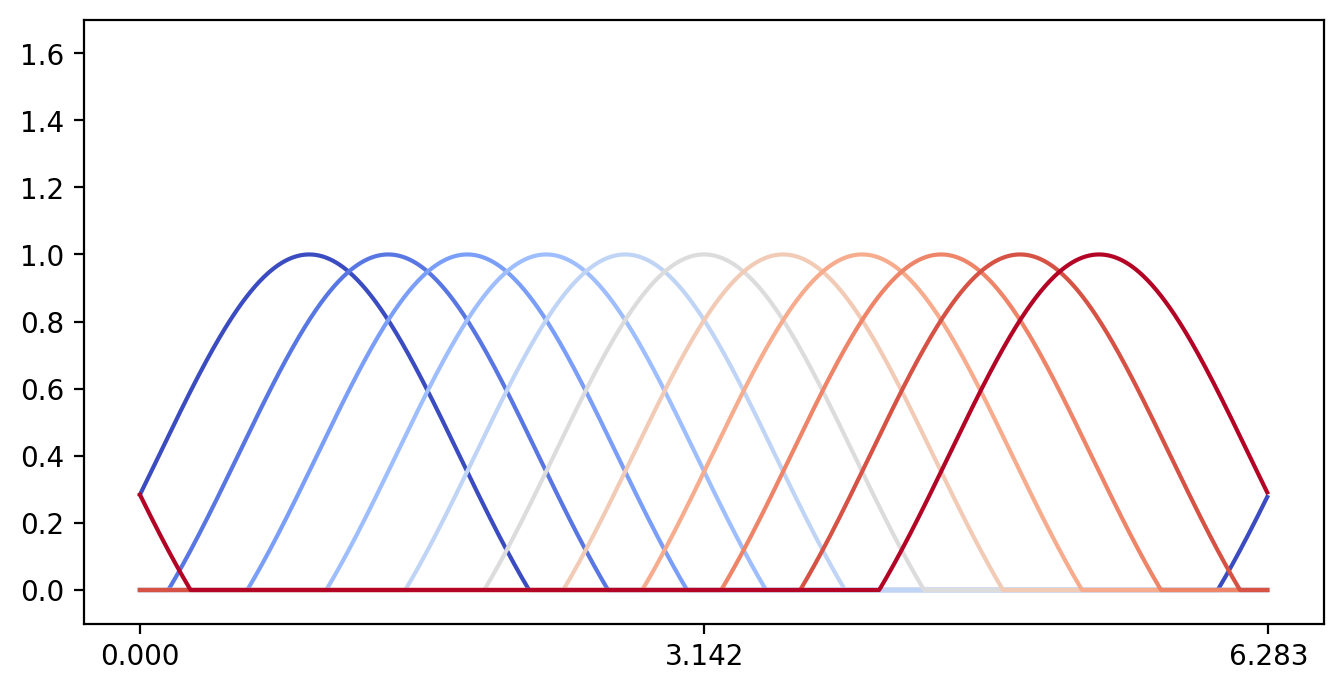

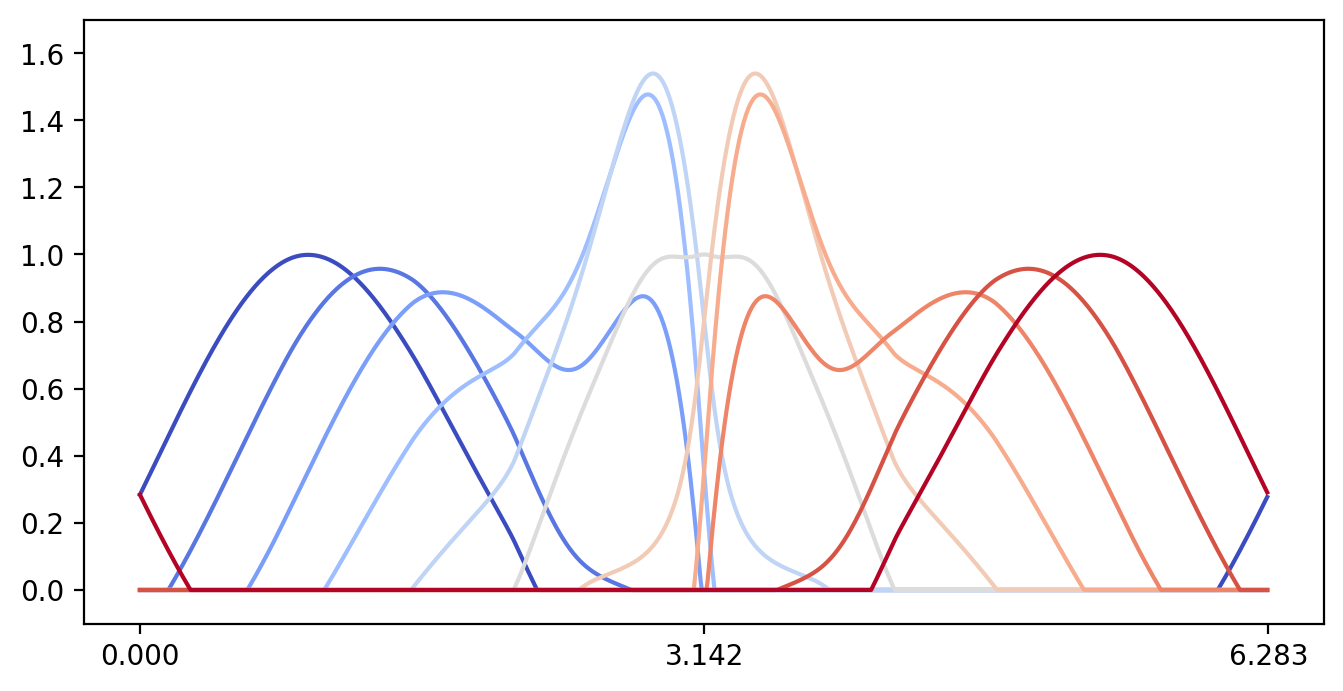

In [23]:
theory_ind = 23

to_layer = 3
theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))
args = theory_results['args']
net = model.Model(args)
print(args)

input_response_mat = np.zeros((1000, args.N))

angles = np.linspace(0, 2*np.pi, 1000, endpoint=False)

for i in range(len(angles)):
    input_response_mat[i] = utils.make_x0(angles[i], args.sig_s, 1000).flatten()
input_response_mat = torch.from_numpy(input_response_mat).float()


init_tuning = net.get_obs(input_response_mat, to_layer=to_layer)

utils.load_theory_from_file(net, theory_results, theory_ind)

final_tuning = net.get_obs(input_response_mat, to_layer=to_layer)

neuron_inds = [150, 220, 290, 360, 430, 500, 570, 640, 710, 780, 850]

colors = plt.cm.coolwarm(np.linspace(0, 1, 701))

plt.figure()
for neuron_ind in neuron_inds:
    plt.plot(angles, init_tuning[:, neuron_ind] / init_tuning.max(), color=colors[neuron_ind - 150])
plt.xticks([0 ,np.pi, 2*np.pi])
# plt.ylim(0, 0.065) # for layer 3
plt.ylim(-0.1, 1.7)
plt.savefig('figures/raw/pre_pl_tuning.svg')

plt.figure()
for neuron_ind in neuron_inds:
    plt.plot(angles, final_tuning[:, neuron_ind] / init_tuning.max(), color=colors[neuron_ind - 150])
plt.xticks([0 ,np.pi, 2*np.pi])
# plt.ylim(0, 0.065)
plt.ylim(-0.1, 1.7)
plt.savefig('figures/raw/post_pl_tuning.svg')


## 6C Normalized slope

In [ ]:
# for a specific parameter, get the slope vector for different stimuli
theory_ind = 23

args.sig_w = vary_values[theory_ind]
_net = model.Model(args)
_net2 = model.Model(args)
utils.load_theory_changes(_net2, [delw1_list[theory_ind], delw2_list[theory_ind], delw3_list[theory_ind]], active_inds_list[theory_ind])

slopes_data = [[], [], []]
test_stim = np.linspace(np.pi, 2*np.pi, 100)
for theta in test_stim:
    args.theta = theta
    stim = utils.GaborStimuli(args, simple_mode=True, verbose=False)
    for l in range(3):
        F0 = utils.matrix_prod(utils.get_effective_weights(_net, stim.x0, full_mat=True)[0], l+1)
        F = utils.matrix_prod(utils.get_effective_weights(_net2, stim.x0, full_mat=True)[0], l+1)

        #slope divided by peak of tuning curves 
        slope0 = (F0 @ stim.x1.t().numpy()).flatten() / stim.delta / response_properties[l]['max0'][23]
        slope = (F @ stim.x1.t().numpy()).flatten() / stim.delta / response_properties[l]['max'][23]
        slopes_data[l].append(np.mean(np.abs(slope)) / np.mean(np.abs(slope0)))
    


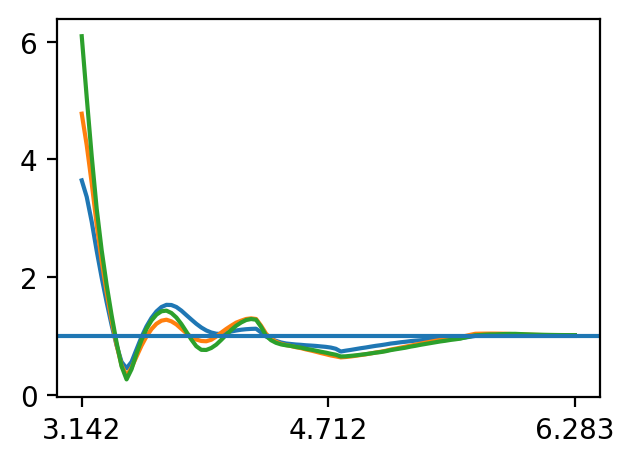

In [ ]:
plt.figure()
for i in range(3):
    plt.plot(test_stim, slopes_data[i])
plt.axhline(1)
plt.xticks([np.pi, np.pi*1.5, np.pi*2])

plt.savefig('figures/raw/normalized_slope_sigsp2_sigwp8.svg')


## 6E  Histogram of phase of first Fourier component

ipykernel_launcher:15: DeprecationWarning: Using scipy.fft as a function is deprecated and will be removed in SciPy 1.5.0, use scipy.fft.fft instead.


([<matplotlib.axis.XTick at 0x7fcaeb0a7d50>,
 [Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')])

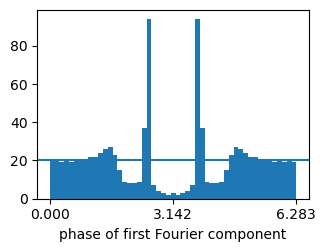

In [ ]:
theory_ind = 23

file_name = 'Saved Results/theory_3L_sigs0P2'

theory_dict = pickle.load(open(file_name, 'rb'))
args = theory_dict['args']
args.sig_w = theory_dict['vary_values'][theory_ind]

_net2 = model.Model(args)

utils.load_theory_from_file(_net2, theory_dict, theory_ind)

mat = utils.get_response_mats(_net2, 3, 0.2, 1000)
from scipy import fft
phases = np.array([np.angle(fft(mat[i])[1]) % (2 * np.pi) for i in range(1000)])
# phases = np.array([np.angle(fft(mat[i])[1]) % (2*np.pi) for i in range(1000)])

plt.figure()
# plt.hist(phases0, bins=51)
plt.hist(phases, bins=np.linspace(0, 2* np.pi, 52, endpoint=True))
plt.axhline(20)
plt.xlabel('phase of first Fourier component')
plt.xticks([0, np.pi, 2 * np.pi])
# plt.savefig('figures/raw/fourier.svg')


## 6F L1 distance between distributions of phases

In [41]:
from scipy.stats import entropy, wasserstein_distance
from scipy.fft import fft

file_name = 'Saved Results/theory_3L_sigs0P2'

theory_dict = pickle.load(open(file_name, 'rb'))
args = theory_dict['args']

# phase_wass_distance = [[], [], []]
phase_euclidean_distance = [[], [], []]
phase_l1_distance = [[], [], []]
for theory_ind in trange(30):

    args.sig_w = theory_dict['vary_values'][theory_ind]

    bl_net = model.Model(args)
    _net2 = model.Model(args)

    utils.load_theory_from_file(_net2, theory_dict, theory_ind)
    for j in range(3):
        mat = utils.get_response_mats(_net2, j+1, 0.2, 1000)
        mat0 = utils.get_response_mats(bl_net, j+1, 0.2, 1000)
        
        phases = np.array([np.angle(fft(mat[i])[1]) % (2 * np.pi) for i in range(1000)])
        phases = np.roll(phases[::-1], 1)

        phases0 = np.array([np.angle(fft(mat0[i])[1]) % (2 * np.pi) for i in range(1000)])
        phases0 = np.roll(phases0[::-1], 1)
        # phase_wass_distance[j].append(wasserstein_distance(phases, phases0))
        phase_euclidean_distance[j].append(np.linalg.norm(phases - phases0))
        phase_l1_distance[j].append(np.abs(phases - phases0).mean())

100%|██████████| 30/30 [00:27<00:00,  1.08it/s]


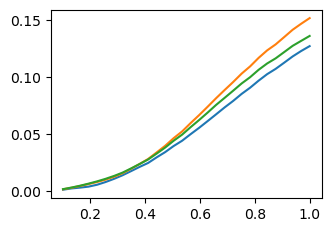

In [42]:


plt.figure()
for i in range(3):
    plt.plot(theory_dict['vary_values'], phase_l1_distance[i])
# plt.savefig('figures/raw/phase_l1_distance.svg')


# Figure 8

## Effect of N, M on linear Fisher information



In [44]:
theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))
t_args = theory_results['args']
t_args.sig_w = 0.8
t_args.sig_s = 0.2
t_args.n_layers = 3
t_args.n_test_trials = 50000


Ns = np.arange(20) * 100 + 50
n_N = len(Ns)

fi_mf = np.zeros((3, n_N))
delta = np.zeros(n_N)

def snr_from_obs(obs):
    half_size = int(len(obs) / 2)
    theta_p = obs[:half_size].mean(0)
    theta_m = obs[half_size:].mean(0)

    signal = (theta_p - theta_m).reshape(-1, 1) / 2

    covar = (np.cov(obs[:half_size].T) + np.cov(obs[half_size:].T)) / 2

    s = np.linalg.svd(covar, compute_uv=False, hermitian=True)

    return float(signal.T @ np.linalg.inv(covar + np.eye(covar.shape[0]) * s[0] * 1e-3) @ signal)

    

for i in trange(n_N):
    t_args.N = 100
    t_args.Nhid = Ns[i]
    stim = utils.GaborStimuli(t_args, verbose=False, simple_mode=True)
    net = model.Model(t_args)
    delta[i] = stim.delta
    w_effs = utils.get_effective_weights(net, stim.x0)[0]
    for j in range(3):
        F = utils.matrix_prod(w_effs, j+1)
        covar = F @ F.T * t_args.noise_var
        signal = F @ stim.x1.numpy().T
        s = np.linalg.svd(covar, compute_uv=False, hermitian=True)
        fi_mf[j, i] = float(signal.T @ np.linalg.inv(covar + np.eye(covar.shape[0]) * s[0] * 1e-6) @ signal)
        # fi_mf[j, i] = float(signal.T @  signal * 100)

100%|██████████| 20/20 [00:03<00:00,  6.00it/s]


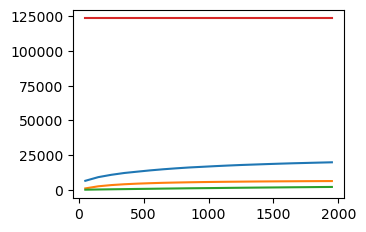

In [45]:
plt.figure()
plt.plot(Ns, fi_mf[0] / delta**2)
plt.plot(Ns, fi_mf[1] / delta**2)
plt.plot(Ns, fi_mf[2] / delta**2)


plt.plot(Ns, 1 / delta**2)
# plt.savefig('figures/raw/fi_over_M_N100_outputnoise.svg')

# plt.plot(Ns, fi_mf[0] / delta**2)

# plt.figure()
# plt.plot(Ns, fi[0])
# plt.plot(Ns, fi[1])
# plt.plot(Ns, fi[2])
# # plt.plot(Ns, 1)

## Information as a function of subsampled neurons
check:theory file name, sigw, sigs, theory index

In [36]:
theory_results = pickle.load(open('Saved Results/theory_3L_sigs1P2', 'rb'))
t_args = theory_results['args']
t_args.sig_w = 0.1
t_args.sig_s = 1.2
t_args.n_layers = 3
t_args.n_test_trials = 50000
t_args.N = 1000
t_args.M = 1000
t_args.theta = np.pi

stim = utils.GaborStimuli(t_args, verbose=False, simple_mode=True)
net = model.Model(t_args)
# utils.load_theory_from_file(net, theory_results, 0)

sub_sample_fraction = np.linspace(0.01, 0.3, 50)
n_avg = 50

sub_sampled_info = np.zeros((3, 50, n_avg))
sub_sampled_info_w_learning = np.zeros((1, 50, n_avg))

w_effs, active_inds = utils.get_effective_weights(net, stim.x0, full_mat=True)

for j in range(3):
    F = utils.matrix_prod(w_effs, j+1)
    covar = F @ F.T * t_args.noise_var
    signal = F @ stim.x1.numpy().T

    
    
    for i in trange(len(sub_sample_fraction)):
        n_neurons_to_read = int(F.shape[0] * sub_sample_fraction[i])
        for k in range(n_avg):
            np.arange(F.shape[0])
            inds = np.random.permutation(np.arange(F.shape[0]))[:n_neurons_to_read]
            subsampled_signal = signal[inds]
            subsampled_covar = covar[inds][:, inds]
            s = np.linalg.svd(subsampled_covar, compute_uv=False, hermitian=True)
            try:
                sub_sampled_info[j, i, k] = float(subsampled_signal.T @ np.linalg.inv(subsampled_covar + np.eye(subsampled_covar.shape[0]) * s[0] * 1e-6) @ subsampled_signal)
            except:
                sub_sampled_info[j, i, k] = 0


            

100%|██████████| 50/50 [00:03<00:00, 15.37it/s]


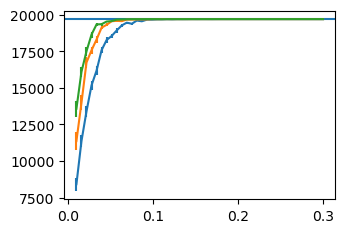

In [37]:
plt.figure()
for layer_ind in range(3):
    plt.errorbar(sub_sample_fraction, sub_sampled_info[layer_ind].mean(1) / stim.delta**2, sub_sampled_info[layer_ind].std(1) / stim.delta**2 / np.sqrt(n_avg))
# plt.plot(sub_sample_fraction, sub_sample_fraction * 1 / stim.delta**2)
plt.axhline(1 / stim.delta**2)
# plt.ylim(800000, 1300000)
# plt.savefig('figures/raw/subsample_info_trained.svg')

## FI if reading from a subsample of neurons from the last layer, but allowing learning

In [33]:
theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))
t_args = theory_results['args']
t_args.sig_w = 0.8
t_args.sig_s = 0.2
t_args.n_layers = 3
t_args.n_test_trials = 50000
t_args.N = 1000
t_args.M = 1000
t_args.theta = np.pi

stim = utils.GaborStimuli(t_args, verbose=False, simple_mode=True)
net = model.Model(t_args)
# utils.load_theory_from_file(net, theory_results, 0)

sub_sample_fraction = np.linspace(0.01, 1, 50)
n_avg = 50

sub_sampled_info_w_learning = np.zeros((1, 50, n_avg))

active_inds = utils.get_effective_weights(net, stim.x0, full_mat=True)[1]
    

for i in trange(len(sub_sample_fraction)):
    
            


            

100%|██████████| 50/50 [00:00<00:00, 740.03it/s]


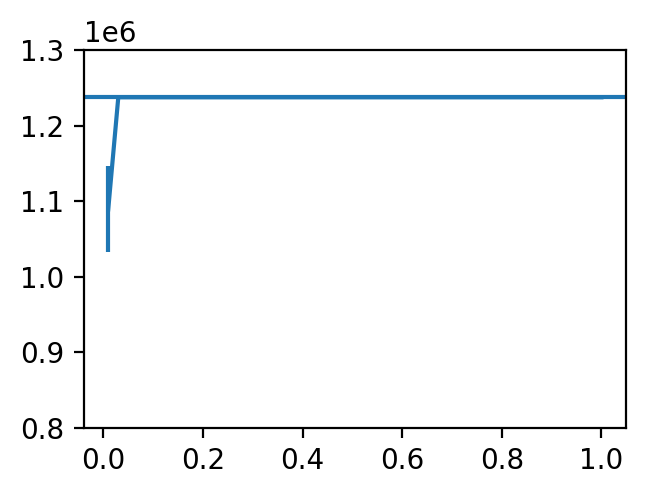

In [36]:
plt.figure()
plt.errorbar(sub_sample_fraction, sub_sampled_info_w_learning[0].mean(1) / stim.delta**2, sub_sampled_info_w_learning[0].std(1) / stim.delta**2 / np.sqrt(n_avg))
plt.ylim(800000, 1300000)
plt.axhline(1 / stim.delta**2)
plt.savefig('figures/raw/subsample_w_learning.svg')

In [330]:
#%% FIG 7 // Data and plotting // number of active neurons, different sig_w



probe_angles = np.linspace(np.pi, 2*np.pi, 500)

theory_ind = 23

theory_dict = pickle.load(open('Saved Results/theory_3L_sigs0p2', 'rb'))

n_active_neurons = np.zeros((3, 500))
    
sig_w_array = theory_dict['vary_values']
delw1 = theory_dict['delw1']; delw2 = theory_dict['delw2']
delw3 = theory_dict['delw3']
act_inds_bl = theory_dict['active_inds']

args2 = theory_dict['args']
args2.sig_w = sig_w_array[theory_ind]

_net = model.Model(args2)
_bl_net = model.Model(args2)
utils.load_theory_changes(_net, [delw1[theory_ind], delw2[theory_ind], delw3[theory_ind]], act_inds_bl[theory_ind])

for j in range(len(probe_angles)):
    args2.theta = probe_angles[j]
    probe_stim = utils.GaborStimuli(args2, simple_mode=True, verbose=False)
    act_inds = utils.get_effective_weights(_net, probe_stim.x0)[1]
    bl_act_inds = utils.get_effective_weights(_bl_net, probe_stim.x0)[1]
    
    for layer_ind in range(3):
        n_active_neurons[layer_ind, j] = len(act_inds[layer_ind + 1]) / len(bl_act_inds[layer_ind + 1])



([<matplotlib.axis.XTick at 0x7fd979b6c390>,
 [Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')])

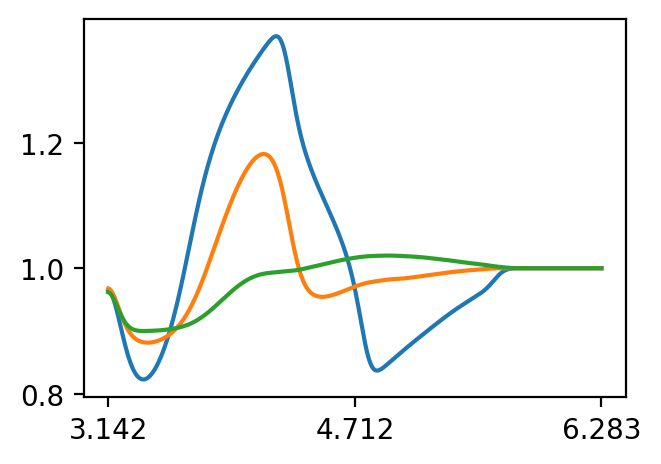

In [331]:
from scipy.ndimage import gaussian_filter1d
smooth_size=7
edge_size = 5
layer_ind = 0

def smooth_but_keep_edges(data, std, edge_size):
    raw = gaussian_filter1d(data, std)
    raw[:edge_size] = data[:edge_size]
    raw[-edge_size:] = data[-edge_size:]
    return raw
plt.figure()
for i in range(3):
    plt.plot(probe_angles, gaussian_filter1d(n_active_neurons[i], smooth_size))
# plt.plot(probe_angles, smooth_but_keep_edges(n_active_neurons[layer_ind], smooth_size, edge_size))
plt.xticks([np.pi, np.pi*1.5, 2*np.pi])
# plt.legend()
# plt.savefig('figures/raw/num_active_neuron_sigs1p2.svg')

## Information in the last layer, trained network, if there is both input and output noise

This part is calculated assumping that both signal and input noise in the last layer scales like sqrt(M).

In [92]:
theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))
t_args = theory_results['args']
t_args.sig_w = 0.8
t_args.sig_s = 0.2
t_args.n_layers = 3
t_args.n_test_trials = 50000


net = model.Model(t_args)
stim = utils.GaborStimuli(args, simple_mode=True, verbose=False)
utils.load_theory_from_file(net, theory_results, 23)
w_effs = utils.get_effective_weights(net, stim.x0)[0]
F = utils.matrix_prod(w_effs)
sig = F @ stim.x1.t().numpy()
rescaled_sig = sig / np.sqrt(t_args.Nhid)
covar = t_args.noise_var * F @ F.T
rescaled_covar = covar / t_args.Nhid

Nhids = np.arange(20) * 500 + 50

info = np.zeros(len(Nhids))

for i, Nhid in enumerate(Nhids):
    sig = rescaled_sig * np.sqrt(Nhid)
    cov = rescaled_covar * Nhid
    info[i] = float(sig.T @ np.linalg.inv(cov + np.eye(cov.shape[0]) * 0.000005) @ sig)

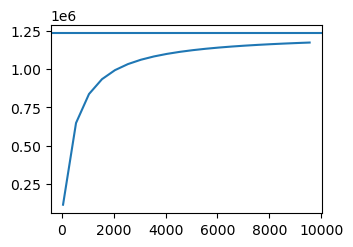

In [95]:
plt.figure()
plt.axhline(1 / stim.delta**2)
plt.plot(Nhids, info / stim.delta**2)
plt.savefig('figures/raw/info_both_noise_over_M.svg')

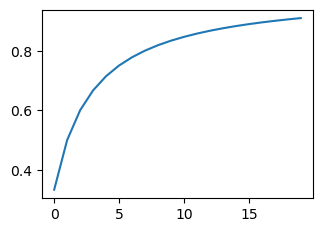

In [64]:
plt.figure()
plt.plot(1 / (1 + 100 / (np.arange(20)*50 + 50)))

## Signal and noise, for different stimuli

Noise refers to the inverse covariance matrix projected on the signal direction.

In [11]:
theory_ind = 0
theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))
args = theory_results['args']
args.sig_w = theory_results['vary_values'][theory_ind]
net = model.Model(args)

theta_tests = np.linspace(np.pi, 2*np.pi, 200)
signal_amp = np.zeros((3, len(theta_tests)))
inv_noise_amp = np.zeros((3, len(theta_tests)))

signal_bl = np.zeros(3); inv_noise_bl = np.zeros(3)

stim = utils.GaborStimuli(args, simple_mode=True, verbose=False)

for i in range(3):
    F0 = utils.matrix_prod(utils.get_effective_weights(net, stim.x0)[0], num_mats=i+1)

    # get baselines
    signal_bl[i] = np.linalg.norm(F0 @ stim.x1.numpy().T)**2

    sig_dir = F0 @ stim.x1.numpy().T; sig_dir /= np.linalg.norm(sig_dir)
    inv_noise_bl[i] = float(sig_dir.T @ np.linalg.inv(F0 @ F0.T + np.eye(F0.shape[0]) * 1e-6) @ sig_dir) / args.noise_var

utils.load_theory_from_file(net, theory_results, theory_ind)

for i in trange(len(theta_tests)):
    args.theta = theta_tests[i]
    stim = utils.GaborStimuli(args, simple_mode=True, verbose=False)
    for j in range(3):
        F = utils.matrix_prod(utils.get_effective_weights(net, stim.x0)[0], num_mats=j+1)
        signal_amp[j, i] = np.linalg.norm(F @ stim.x1.numpy().T)**2

        # projection of the inverse covariance on signal directions
        sig_dir = F @ stim.x1.numpy().T; sig_dir /= np.linalg.norm(sig_dir)
        covar = (F @ F.T + np.eye(F.shape[0]) * 1e-6) * args.noise_var
        inv_noise_amp[j, i] = sig_dir.T @ np.linalg.inv(covar) @ sig_dir



100%|██████████| 200/200 [00:06<00:00, 32.21it/s]


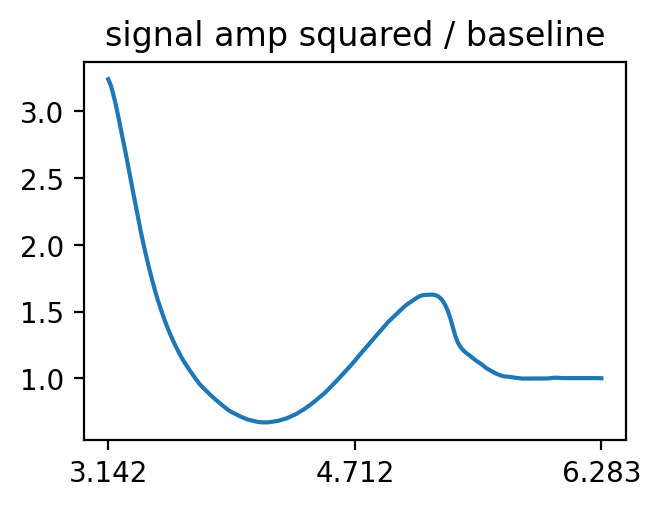

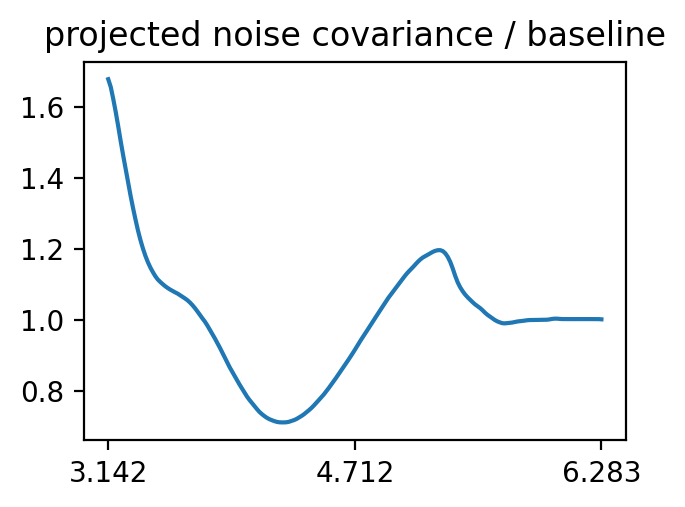

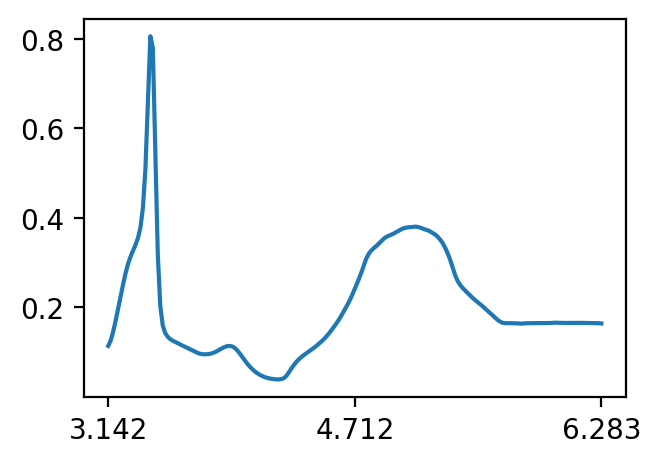

In [17]:
from scipy.ndimage import gaussian_filter1d
smooth_size = 1

plt.figure()
# for i in range(3):
#     plt.plot(theta_tests, signal_amp[i] / signal_bl[i])
plt.plot(theta_tests, gaussian_filter1d(signal_amp[2], smooth_size) / signal_bl[2])
plt.title('signal amp squared / baseline')
# plt.grid()
plt.xticks([np.pi, np.pi*1.5, np.pi*2])
plt.savefig('figures/raw/signal_amp.svg')

plt.figure()
# for i in range(3):
#     plt.plot(theta_tests, 1 / noise_amp[i] * noise_bl[i])
plt.plot(theta_tests, 1 / gaussian_filter1d(inv_noise_amp[2], smooth_size) * inv_noise_bl[2])
plt.title('projected noise covariance / baseline')
plt.xticks([np.pi, np.pi*1.5, np.pi*2])
# plt.grid()
plt.savefig('figures/raw/noise_amp.svg')

fi = signal_amp[2] * noise_amp[2]
bl_fi = signal_bl[2] * noise_bl[2]
plt.figure()
plt.plot(theta_tests, gaussian_filter1d(fi - bl_fi, smooth_size) / np.max(fi - bl_fi))
plt.xticks([np.pi, np.pi*1.5, np.pi*2])
plt.savefig('figures/raw/transfer.svg')

# Supplementary Figures

In [ ]:

#%% Fig 2 // Data and Plot // J/J_input as a function of N, Nhid

args2 = copy.copy(args)
args2.n_layers = 1
nrange = [25, 50, 100, 200, 400, 800, 1600]
nhid_range = [200, 400, 800]

args2.sig_s = 0.2; args2.sig_w = 0.8
plt.figure()
for nhid in nhid_range:
    args2.Nhid = nhid
    info_list = []
    for n in nrange:
        args2.N = n
        stim = train_utils.GaborStimuli(args2, verbose=False, simple_mode=True)
        net = model.Model(args2)
        info_list.append(r_utils.get_mean_field_fi(net, stim))
    plt.plot(info_list); plt.xticks(range(len(nrange)), nrange)

plt.ylim(0.3, 0.45)

In [ ]:
#%% FIG 3 /// DATA /// linear and nonlinear readout comparison

torch.set_grad_enabled(True)
args2 = copy.copy(args)
args2.sig_s = 1.2
args2.N = 50
args2.Nhid = 50
args2.n_test_trials = 50000
args2.n_layers=1

stim2 = train_utils.GaborStimuli(args2)

def get_error(name):
    utils.process_raw_data(name)
    list_of_datasets = utils.list_datasets(keyword=name)
    dataset = utils.load_dataset(0, list_of_datasets, attribute='sig_w')

    data_sig_w = np.array([data['args'].sig_w for data in dataset])
    data_error = np.array([data['error'][-1] for data in dataset])
    sort = np.argsort(data_sig_w)
    return data_sig_w[sort], data_error[sort], dataset

sig_w, error, dataset = get_error('2Layers_SquaredError_GradDescent_Freeze0_N50_vary_sigw_10_runs')
plt.figure()
error = error.reshape((len(np.unique(sig_w)), -1))
plt.plot(np.unique(sig_w), error.min(axis=1), marker='o', label='1L, nonlinear decoder')

sig_w, error, dataset = get_error('1Layers_SquaredError_GradDescent_Freeze0_N50_vary_sigw_10_runs')
error = error.reshape((len(np.unique(sig_w)), -1))
plt.plot(np.unique(sig_w), error.min(axis=1), marker='o', label='1L, linear decoder')

sig_w, error, dataset = get_error('3Layers_SquaredError_GradDescent_Freeze0_1_N50_vary_sigw_10_runs')
error = error.reshape((len(np.unique(sig_w)), -1))
plt.plot(np.unique(sig_w), error.min(axis=1), marker='o', label='2L, nonlinear decoder')

sig_w, error, dataset = get_error('2Layers_SquaredError_GradDescent_Freeze0_1_N50_vary_sigw_10_runs')
error = error.reshape((len(np.unique(sig_w)), -1))
plt.plot(np.unique(sig_w), error.min(axis=1), marker='o', color='k', label='2L, linear decoder')

sig_w, error, dataset = get_error('4Layers_SquaredError_GradDescent_Freeze012_N50_vary_sigw_10_runs')
error = error.reshape((len(np.unique(sig_w)), -1))
plt.plot(np.unique(sig_w), error.min(axis=1), marker='o', label='3L, nonlinear decoder')

sig_w, error, dataset = get_error('3Layers_SquaredError_GradDescent_Freeze012_N50_vary_sigw_10_runs')
error = error.reshape((len(np.unique(sig_w)), -1))
plt.plot(np.unique(sig_w), error.min(axis=1), marker='o', label='3L, linear decoder')

plt.xlim(0.05, 0.5)
plt.axhline(stim2.mld_err)
plt.legend(bbox_to_anchor=(1.01, 1))
plt.savefig('figures/1_to_3_layer_linear_vs_nonlinear_decoder.svg')


#%% FIG 3 // DATA AND PLOTTING // HISTOGRAMS of h
torch.set_grad_enabled(False)
args2 = copy.copy(args)
args2.sig_s = 0.2
args2.N = 100
args2.Nhid = 100
args2.n_test_trials = 50000
args2.n_layers=3
args2.sig_w = 0.8
args2.noise_var = 0.01

stim2 = train_utils.GaborStimuli(args2)
net2 = model.Model(args2)
obs2 = net2.get_obs(stim2.te_stim(), to_layer=2).numpy()
h3 = obs2 @ net2.Ws[-1].T

neuron_ind = int(args2.N * 0.2)
bins = np.linspace(-0.0150, -0.0050, 200)

hist_plus = np.histogram(h3[:args2.n_test_trials, neuron_ind], bins, density=True)[0]
hist_minus = np.histogram(h3[args2.n_test_trials:, neuron_ind], bins, density=True)[0]

plt.figure(figsize=(6, 2))
plt.plot(bins[:199], hist_plus)
plt.plot(bins[:199], hist_minus)
# plt.hist(h3[args2.n_test_trials:, neuron_ind], bins=bins, alpha=0.5, density=True)

plt.savefig('figures/raw/input_histogram_3rdLayer_N100.svg')



#%% FIG 3 /// DATA /// del h as a function of N
name = '3Layers_SquaredError_GradDescent_Standard_'

# utils.process_raw_data(name)  # This will overwrite the data file. Make sure this line is usually commented out.

dataset = utils.find_and_load_data(name, attribute='N')
print(dataset[0]['args'])
dataset_N = []
dataset_x0 = []
dataset_x0_sqrt_N = []
dataset_x1 = []
dataset_phi_prime_difference = []


for data in dataset:
    dataset_N.append(data['args'].N)
    stim = train_utils.GaborStimuli(data['args'], simple_mode=True, verbose=False)
    dataset_x0.append(np.linalg.norm(utils.recover_matrix(data['delW'][0][-1]) @ stim.x0_normed.t().numpy()))
    dataset_x0_sqrt_N.append(dataset_x0[-1] * np.sqrt(data['args'].N))
    dataset_x1.append(np.linalg.norm(utils.recover_matrix(data['delW'][0][-1]) @ stim.x1_normed.t().numpy()))
    dataset_phi_prime_difference.append(utils.cos(data['phi_prime'][-1][-1], data['phi_prime'][-1][0]))

plt.figure()
plt.scatter(dataset_N, dataset_x0)
plt.scatter(dataset_N, dataset_x1)

plt.figure()
plt.scatter(dataset_N, dataset_phi_prime_difference)

plt.figure()
plt.scatter(dataset_N, dataset_x0_sqrt_N)

dataset_N = []
h1_diff = []
h2_diff = []
h3_diff = []
for data in dataset:
    dataset_N.append(data['args'].N)
    stim = train_utils.GaborStimuli(data['args'], simple_mode=True, verbose=False)
    _net = model.Model(data['args'])
    h10 = _net.Ws[0] @ stim.x0.numpy().T
    h20 = _net.Ws[1] @ _net.get_obs(stim.x0, to_layer=1).numpy().T
    h30 = _net.Ws[2] @ _net.get_obs(stim.x0, to_layer=2).numpy().T
    utils.load_GD_changes(_net, data)
    h11 = _net.Ws[0] @ stim.x0.numpy().T
    h21 = _net.Ws[1] @ _net.get_obs(stim.x0, to_layer=1).numpy().T
    h31 = _net.Ws[2] @ _net.get_obs(stim.x0, to_layer=2).numpy().T
    h1_diff.append(np.linalg.norm(h11 - h10) / np.linalg.norm(h10))
    h2_diff.append(np.linalg.norm(h21 - h20) / np.linalg.norm(h20))
    h3_diff.append(np.linalg.norm(h31 - h30) / np.linalg.norm(h30))

#%% FIG 3 /// PLOTTING /// del h as a function of N
plt.figure(figsize=(3, 4))
plt.scatter(np.log(dataset_N)[:6], np.log(h1_diff)[:6])
plt.scatter(np.log(dataset_N)[:6], np.log(h2_diff)[:6])
plt.scatter(np.log(dataset_N)[:6], np.log(h3_diff)[:6])
plt.xlabel('logN')
plt.ylabel('log del h')
plt.savefig('figures/raw/changes_to_h_3_layers.svg')

plt.figure()
# plt.plot(h30)
# plt.plot(h31)

#%%
plt.figure()
plt.imshow(utils.recover_matrix(dataset[5]['delW'][-1][-1]))

## Compare tuning curves in the 3rd layer if only W1 is modified

In [68]:
file_name = 'Saved Results/theory_3L_sigs0P2'
theory_dict = pickle.load(open(file_name, 'rb'))
args = theory_dict['args']
stim = utils.GaborStimuli(args, simple_mode=True)

l3_full, l3_bl, l3_w1, l3_w2, l3_w3 = np.zeros(30), np.zeros(30), np.zeros(30), np.zeros(30), np.zeros(30)
l1_full, l1_bl = np.zeros(30), np.zeros(30)
for theory_ind in range(len(theory_dict['vary_values'])):

    args.sig_w = theory_dict['vary_values'][theory_ind]

    trained_net = model.Model(args)
    bl_net = model.Model(args)
    net1 = model.Model(args) # only W1 is modified
    net2 = model.Model(args) # only W2
    net3 = model.Model(args) # only W3

    utils.load_theory_from_file(trained_net, theory_dict, theory_ind)

    net1.L0.weight.data = trained_net.L0.weight.data

    net2.L1.weight.data = trained_net.L1.weight.data
    net3.L2.weight.data = trained_net.L2.weight.data

    for net, slope_list in zip([trained_net, bl_net, net1, net2, net3], [l3_full, l3_bl, l3_w1, l3_w2, l3_w3]):
        F = utils.matrix_prod(utils.get_effective_weights(net, stim.x0)[0], 3)
        # slope_list[theory_ind] = np.linalg.norm(F @ stim.x1.numpy().T)
        slope_list[theory_ind] = np.mean(np.abs((F @ stim.x1.numpy().T)))

    for net, slope_list in zip([trained_net, bl_net], [l1_full, l1_bl]):
        F = utils.get_effective_weights(net, stim.x0)[0][0]
        slope_list[theory_ind] = np.mean(np.abs((F @ stim.x1.numpy().T)))

calc_MLD(): MLD error is 0.15865647220940177


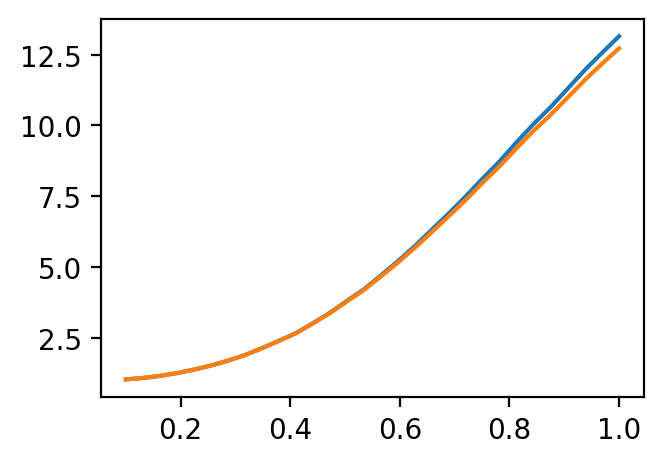

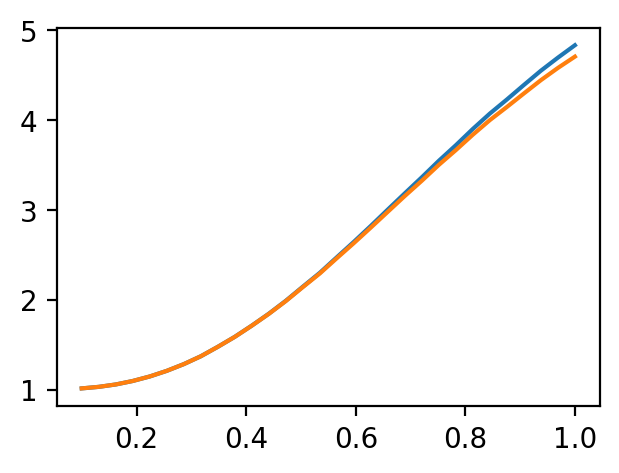

In [71]:
plt.figure()
plt.plot(theory_dict['vary_values'], l3_full / l3_bl)

plt.plot(theory_dict['vary_values'], l3_w1 * l3_w2 * l3_w3 / l3_bl**3)
plt.savefig('figures/raw/l3_sharpness_changes_w1w2w3.svg')
plt.figure()
plt.plot(theory_dict['vary_values'], l1_full / l1_bl)
plt.plot(theory_dict['vary_values'], l3_w1 / l3_bl)
plt.savefig('figures/raw/delw3_tuning_onlyw1.svg')

## Analysis of noise correlation (signal, noise, signal-noise alignment)

In [86]:
file_name = 'Saved Results/theory_3L_sigs0P2'
theory_dict = pickle.load(open(file_name, 'rb'))
args = theory_dict['args']
stim = utils.GaborStimuli(args, simple_mode=True)
sigw_arr = theory_dict['vary_values']

sig_noise_overlap0, sig_noise_overlap1 = np.zeros(30), np.zeros(30)
sig_spec0, sig_spec1, noise_spec0, noise_spec1 = np.zeros((30, args.N)), np.zeros((30, args.N)), np.zeros((30, args.N)), np.zeros((30, args.N))

def decompose_noise(covariance, signal):
    _, v, d = np.linalg.svd(covariance)
    noise = v
    sig = (d @ signal)**2
    return noise, sig.flatten()


to_layer_ind = 2

for theory_ind in range(len(sigw_arr)):
    args.sig_w = sigw_arr[theory_ind]
    bl_net = model.Model(args)

    F_init = utils.matrix_prod(utils.get_effective_weights(bl_net, stim.x0, full_mat=True)[0], to_layer_ind + 1)

    utils.load_theory_from_file(bl_net, theory_dict, theory_ind)

    F_final = utils.matrix_prod(utils.get_effective_weights(bl_net, stim.x0, full_mat=True)[0], to_layer_ind + 1)
    sig_init = F_init @ stim.x1.numpy().T
    sig_final = F_final @ stim.x1.numpy().T

    covar_init = F_init @ F_init.T * args.noise_var
    covar_final = F_final @ F_final.T * args.noise_var

    noise0, sig0 = decompose_noise(covar_init, sig_init)
    noise1, sig1 = decompose_noise(covar_final, sig_final)
    
    sig_noise_overlap0[theory_ind] = utils.cos(noise0, sig0)
    sig_noise_overlap1[theory_ind] = utils.cos(noise1, sig1)
    sig_spec0[theory_ind] = sig0; sig_spec1[theory_ind] = sig1
    noise_spec0[theory_ind] = noise0; noise_spec1[theory_ind] = noise1




calc_MLD(): MLD error is 0.15865647220940177


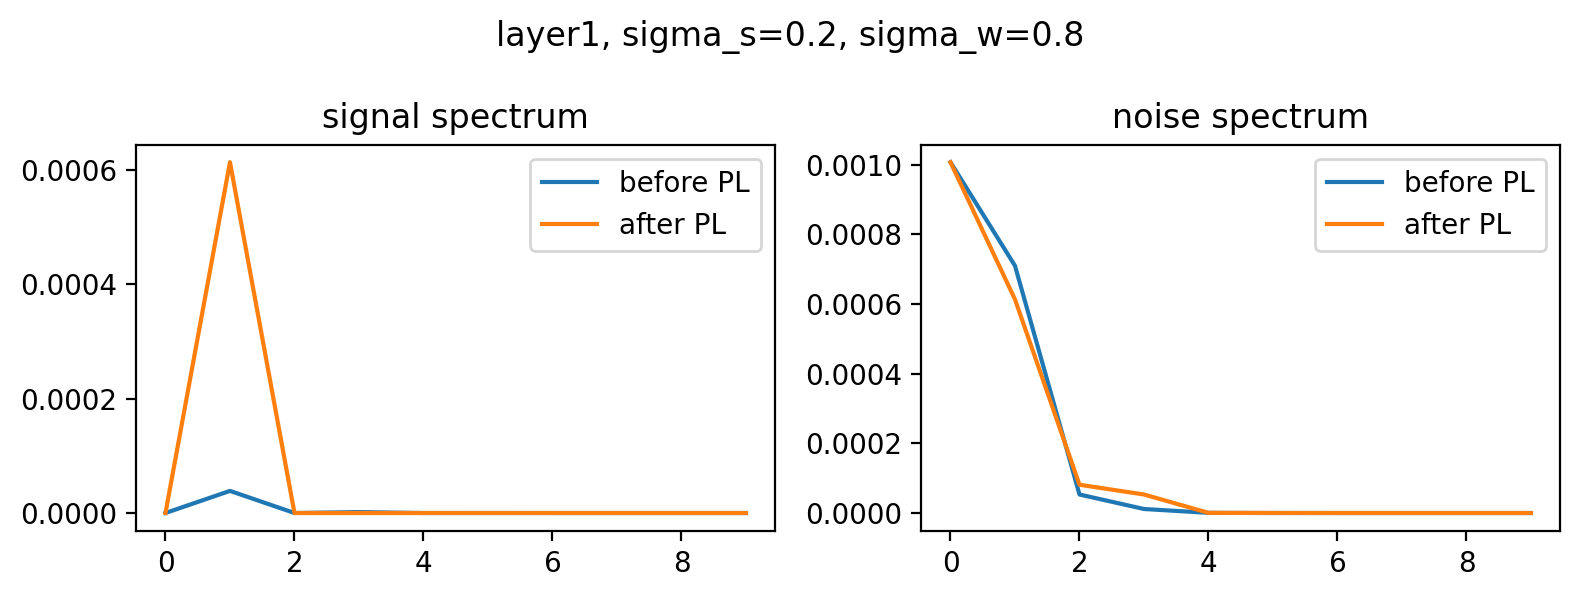

In [78]:
ind = 23  # determines the sigma_w analyzed
fig = plt.figure(figsize=(8, 3))
fig.add_subplot(121)
plt.plot(sig_spec0[ind][:10], label='before PL')
plt.plot(sig_spec1[ind][:10], label='after PL')
plt.legend(); plt.title('signal spectrum')


fig.add_subplot(122)
plt.plot(noise_spec0[ind][:10], label='before PL')
plt.plot(noise_spec1[ind][:10], label='after PL')
plt.legend(); plt.title('noise spectrum')
plt.suptitle(f'layer{to_layer_ind + 1}, sigma_s=0.2, sigma_w=0.8')
plt.tight_layout()

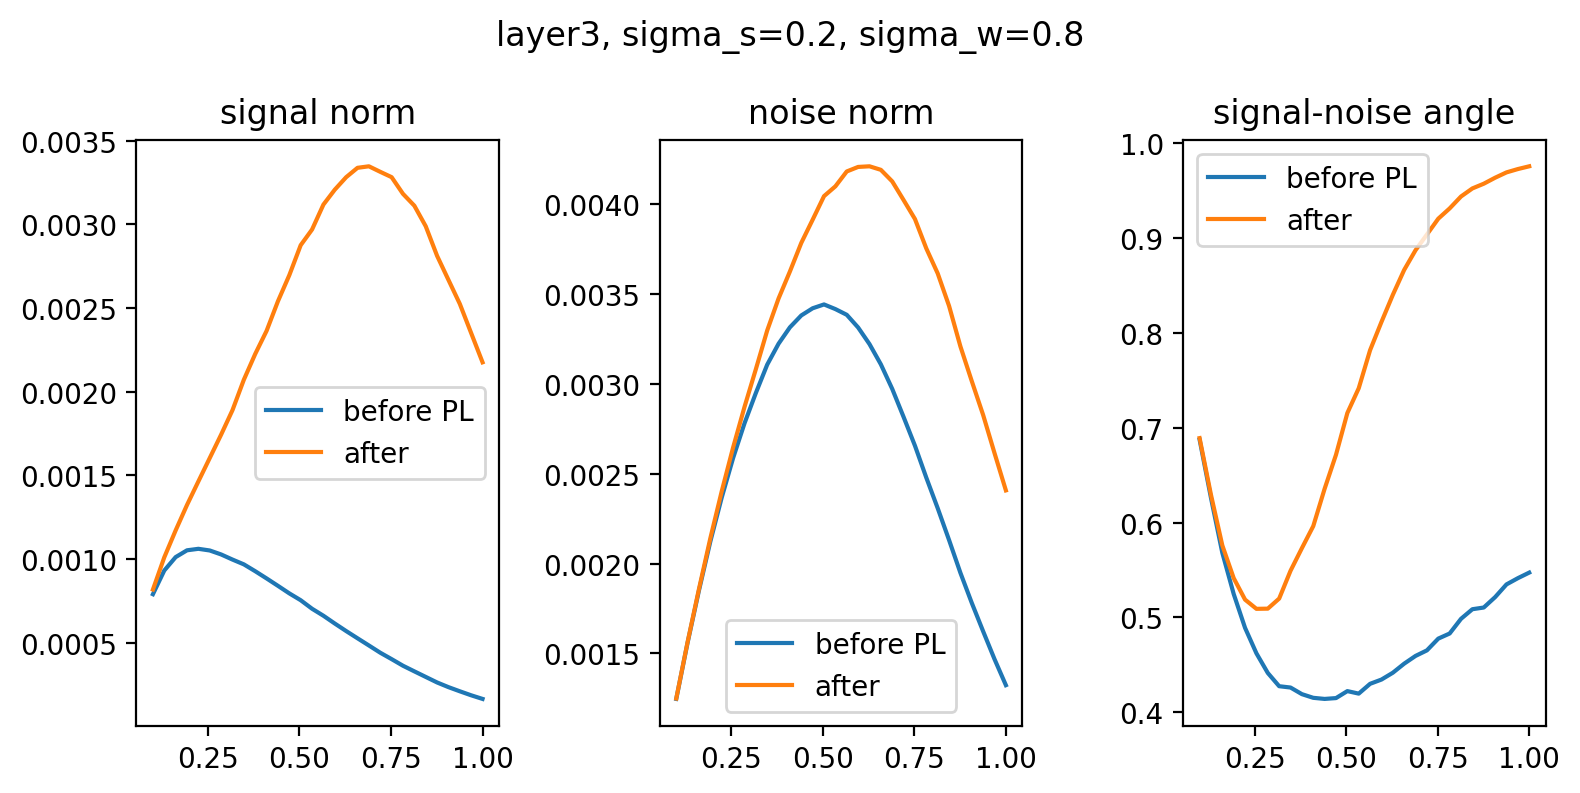

In [87]:
fig = plt.figure(figsize=(8, 4))
fig.add_subplot(131)
plt.plot(sigw_arr, np.sqrt(sig_spec0.sum(axis=1)), label='before PL')
plt.plot(sigw_arr, np.sqrt(sig_spec1.sum(axis=1)), label='after')
plt.title('signal norm'); plt.legend()

fig.add_subplot(132)
plt.plot(sigw_arr, np.sqrt(noise_spec0.sum(axis=1)), label='before PL')
plt.plot(sigw_arr, np.sqrt(noise_spec1.sum(axis=1)), label='after')
plt.title('noise norm'); plt.legend()

fig.add_subplot(133)
plt.plot(sigw_arr, sig_noise_overlap0, label='before PL')
plt.plot(sigw_arr, sig_noise_overlap1, label='after')
plt.title('signal-noise angle'); plt.legend()
plt.suptitle(f'layer{to_layer_ind + 1}, sigma_s=0.2, sigma_w=0.8')
plt.tight_layout()
# plt.savefig('figures/raw/signal_and_noise_layer3_sigs_P2.svg')

In [17]:
r_mat3.shape

(1000, 1000)

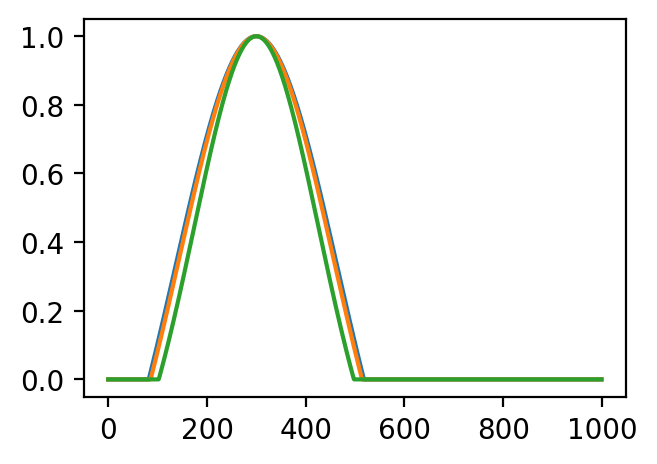

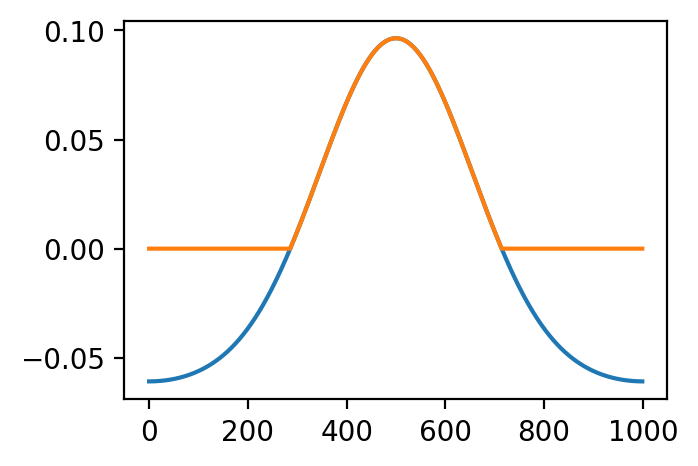

In [30]:
args.sig_w = 0.8
args.sig_s = 0.2
bl_net = model.Model(args)
r_mat3 = utils.get_response_mats(bl_net, 3, args.sig_s, args.N)
r_mat2 = utils.get_response_mats(bl_net, 2, args.sig_s, args.N)
r_mat1 = utils.get_response_mats(bl_net, 1, args.sig_s, args.N)

plt.figure()
plt.plot(r_mat3[:, 300] / r_mat3[:, 300].max())
plt.plot(r_mat2[:, 300] / r_mat2[:, 300].max())
plt.plot(r_mat1[:, 300] / r_mat1[:, 300].max())

plt.figure()
plt.plot(bl_net.Ws[0] @ r_mat1[500].reshape(-1, 1))
plt.plot(r_mat2[500])

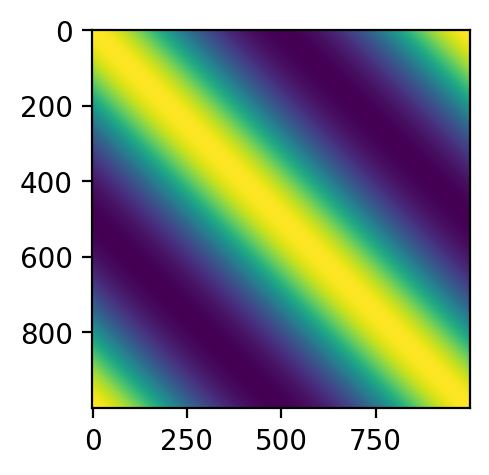

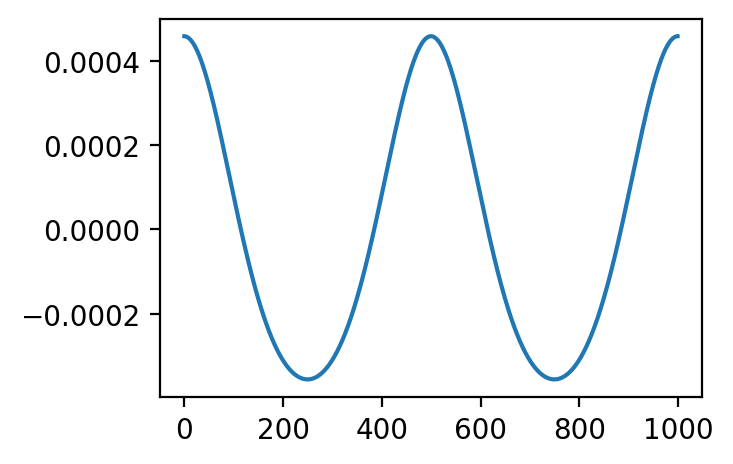

In [5]:
plt.figure()
plt.imshow(net.Ws[0] @ net.Ws[0].T)

plt.figure()
plt.plot(np.diagonal(np.rot90(net.Ws[0] @ net.Ws[0].T)))

In [7]:
args.sig_w = 0.8
net = model.Model(args)
np.linalg.norm(net.Ws[0])

0.677391

In [ ]:
torch.set_grad_enabled(False)
args2 = copy.copy(args)
args2.sig_s = 0.2
args2.N = 1000
args2.Nhid = 1000
args2.n_test_trials = 50000
args2.n_layers=3
args2.sig_w = 0.8

dataset = utils.find_and_load_data('3L_MSE_GD_sigw_sigs0p2_lambdaP015_batch1000_', 'sig_w')
theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P2', 'rb'))


# normalized changes from theory
delw1 = []; delw2 = []; delw3 = []

for i in range(30):
    args2.sig_w = theory_results['vary_values'][i]
    _net = model.Model(args2)
    delw1.append(np.linalg.norm(theory_results['delw1'][i]) /
                       np.linalg.norm(_net.Ws[0]))
    delw2.append(np.linalg.norm(theory_results['delw2'][i]) /
                       np.linalg.norm(_net.Ws[0]))
    delw3.append(np.linalg.norm(theory_results['delw3'][i]) /
                       np.linalg.norm(_net.Ws[0]))

# Compute dela / a and del w / w from simulation
delw1_data = []; delw2_data = []; delw3_data = []
sigw_data = []
for _data in dataset:
    sigw_data.append(_data['args'].sig_w)
    args2.sig_w = _data['args'].sig_w
    _net = model.Model(args2)

    delw1_data.append(np.linalg.norm(_data['delW'][0][-1]['s']) / np.linalg.norm(_net.Ws[0]))
    delw2_data.append(np.linalg.norm(_data['delW'][1][-1]['s']) / np.linalg.norm(_net.Ws[1]))
    delw3_data.append(np.linalg.norm(_data['delW'][2][-1]['s']) / np.linalg.norm(_net.Ws[2]))


## Changes to W1 vs W1 + W2 + W3

In [9]:
file_name = 'Saved Results/theory_3L_sigsP2_frozenW2W3'
theory_dict = pickle.load(open(file_name, 'rb'))

delw1_frozen = np.array([np.linalg.norm(m) for m in theory_dict['delw1']])

file_name = 'Saved Results/theory_3L_sigs0P2'
theory_dict = pickle.load(open(file_name, 'rb'))

delw1_norm = np.array([np.linalg.norm(m) for m in theory_dict['delw1']])
delw2_norm = np.array([np.linalg.norm(m) for m in theory_dict['delw2']])
delw3_norm = np.array([np.linalg.norm(m) for m in theory_dict['delw3']])

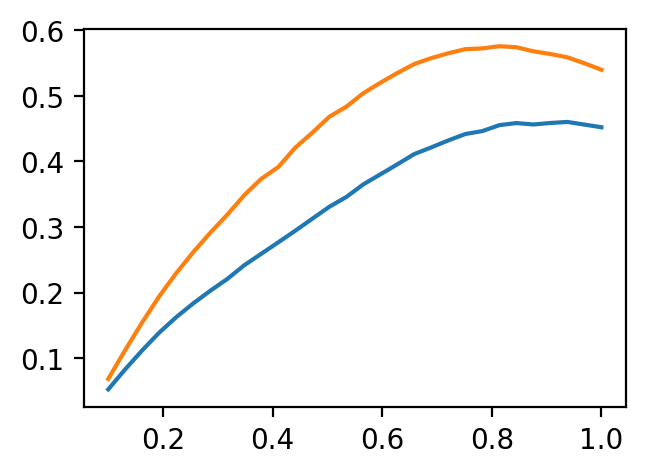

In [12]:
plt.figure()
plt.plot(theory_dict['vary_values'], delw1_frozen)
plt.plot(theory_dict['vary_values'], delw1_norm + delw2_norm + delw3_norm)
plt.savefig('figures/raw/l3_changes_frozenw2w3.svg')

## Learning rate effects

In [ ]:
name = '3L_MSE_GD_eta_sigs0p2_sigw0p8_reps.data'
dataset = utils.find_and_load_data(name, attribute='eta')

[-2.5 -3.  -1.5 -2.  -3.5 -4.  -1.  -3.5 -1.  -4.  -4.  -3.  -2.5 -2.
 -1.5 -3.5 -3.5 -1.  -4.  -1.5 -1.5 -2.  -2.5 -3.  -1.  -4.  -2.  -1.5
 -3.  -2.5 -4.  -1.  -3.5 -1.  -3.5 -4.  -1.  -3.  -2.5 -1.5 -2.  -3.
 -3.5 -2.  -1.5 -3.  -2.5 -3.5 -1.  -4.  -2.5 -3.  -2.5 -3.  -1.5 -2.
 -4.  -1.  -3.5 -2.  -1.5 -1.  -4.  -3.5 -1.5 -2.  -3.  -2.5 -2.5 -2. ]


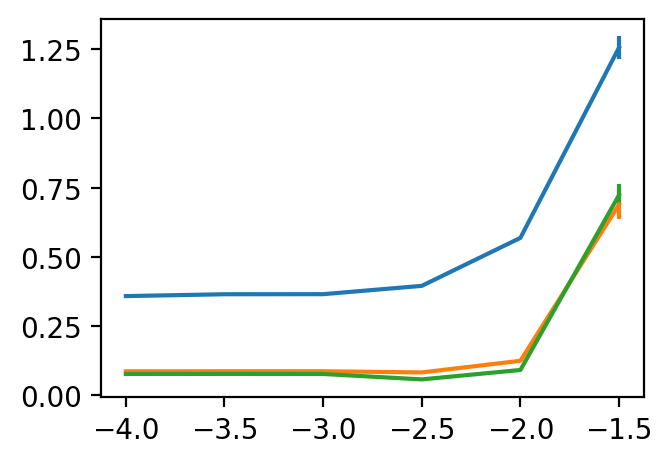

In [39]:
all_eta = [np.linalg.norm(data['a'][-1]) * data['args'].eta for data in dataset]
log10_eta = np.round(np.log10(all_eta) * 2) / 2
delw1 = np.array([np.linalg.norm(data['delW'][0][-1]['s']) for data in dataset])
delw2 = np.array([np.linalg.norm(data['delW'][1][-1]['s']) for data in dataset])
delw3 = np.array([np.linalg.norm(data['delW'][2][-1]['s']) for data in dataset])
print(log10_eta)

# reshape data matrices to be 7*10
# eta = 0.1 result is not shown because it diverges
delw1 = delw1[np.argsort(log10_eta)].reshape(7, 10)[:6]
delw2 = delw2[np.argsort(log10_eta)].reshape(7, 10)[:6]
delw3 = delw3[np.argsort(log10_eta)].reshape(7, 10)[:6]
total = delw1 + delw2 + delw3

x_axis = np.unique(log10_eta)[:6]
plt.figure()
plt.errorbar(x_axis, delw1.mean(1), np.std(delw1, 1) / np.sqrt(10))
plt.errorbar(x_axis, delw2.mean(1), np.std(delw2, 1) / np.sqrt(10))
plt.errorbar(x_axis, delw3.mean(1), np.std(delw3, 1) / np.sqrt(10))
# plt.errorbar(x_axis, total.mean(1), np.std(total, 1) / np.sqrt(10))
# plt.ylim(0, 1)
plt.savefig('figures/raw/delw_over_eta.svg')

## Interference from simulated learning using different learning rates

In [64]:
name = '1L_MSE_GD_eta_sigs0p2_sigw0p8_reps'
# utils.process_raw_data(name, skip_fails=True)
dataset = utils.find_and_load_data(name, attribute='sig_w')

#0     1L_MSE_GD_eta_sigs0p2_sigw0p8_reps

 Loaded dataset: *** 1L_MSE_GD_eta_sigs0p2_sigw0p8_reps ***, 
 created 2021-03-18 17:44:16.286828 

#    |N    |L    |error  |DelW1  |#entries|sig_w
0    |1000 |1    |0.1586 |5109.3657 |21     |0.8  
1    |1000 |1    |0.1584 |253.4018 |27     |0.8  
2    |1000 |1    |0.1596 |0.1562 |9      |0.8  
3    |1000 |1    |0.1572 |10.4721 |16     |0.8  
4    |1000 |1    |0.1594 |0.1536 |8      |0.8  
5    |1000 |1    |0.1584 |0.8634 |24     |0.8  
6    |1000 |1    |0.1584 |4705.7939 |12     |0.8  
7    |1000 |1    |0.1587 |102.6045 |8      |0.8  
8    |1000 |1    |0.1598 |3.8343 |49     |0.8  
9    |1000 |1    |0.1595 |0.1580 |10     |0.8  
10   |1000 |1    |0.1584 |330.6229 |7      |0.8  
11   |1000 |1    |0.1589 |1.0510 |48     |0.8  
12   |1000 |1    |0.1601 |222.9846 |10     |0.8  
13   |1000 |1    |0.1597 |1.0222 |36     |0.8  
14   |1000 |1    |0.1580 |6.6586 |20     |0.8  
15   |1000 |1    |0.1583 |173.6042 |27     |0.8  
16   |1000 |1    |0.158

In [5]:
dataset[0].keys()

dict_keys(['loss', 'error', 'a', 'v_eff', 'x1', 'theta1', 'theta2', 'phi_prime', 'delW', 'args', '_time', 'errors_with_original_readouts', 'errors_with_new_readouts'])

In [9]:
data['args']

Namespace(BATCH_NAME='3L_MSE_GD_eta_sigs0p2_sigw0p8_reps', N=1000, Nhid=1000, TRIAL_IND=50, _duration=1037.1602683067322, cluster=1, eta=0.0003135617880616337, f=None, lambda2=0.0, loss='MSE', n_layers=3, n_learn=40000000, n_test_trials=2500, n_train_trials=50, noise_var=0.01, nonlinearity='relu', sig_s=0.2, sig_w=0.8, test_interval=10000, theta=3.141592653589793)

In [34]:
data['args'].eta * np.linalg.norm(data['a'][0])

0.009999998976531255

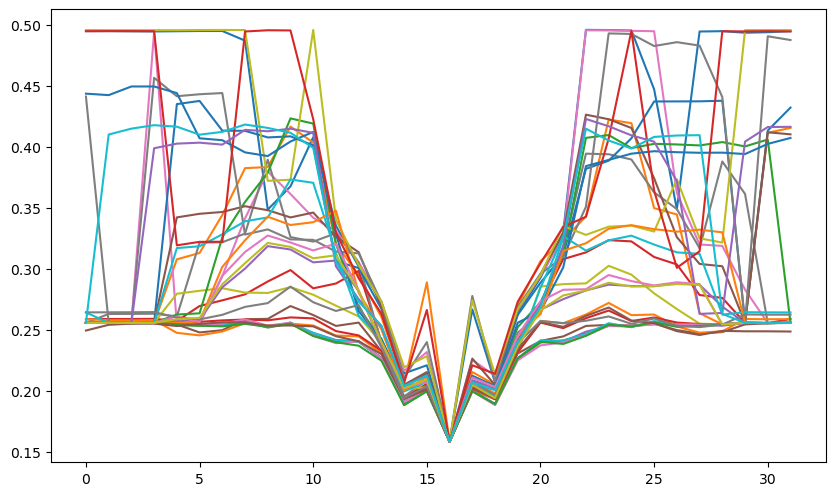

In [66]:
plt.figure(figsize=(10, 6))
for data in dataset:
    # if data['args'].eta * np.linalg.norm(data['a'][-1]) == 0.001:
    try:
        # vec = utils.error_to_fi(data['errors_with_new_readouts'])
        # plt.plot((vec  - vec[0]) / (1 - vec[0]))
        plt.plot(data['errors_with_new_readouts'])
    except: continue

In [55]:
data.keys()

dict_keys(['loss', 'error', 'a', 'v_eff', 'x1', 'theta1', 'theta2', 'phi_prime', 'delW', 'args', '_time'])

calc_MLD(): MLD error is 0.15865647220940177


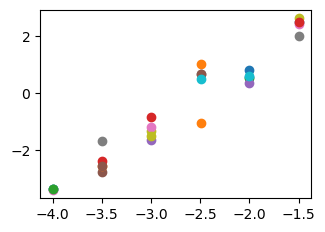

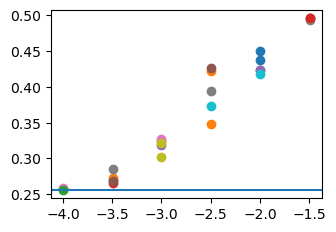

In [68]:
plt.figure()
for data in dataset:
    try: plt.scatter(np.log10(data['args'].eta * np.linalg.norm(data['a'][0])), np.log10(np.linalg.norm(data['a'][-1] - data['a'][0]) / np.linalg.norm(data['a'][0])))
    except: continue

plt.figure()
for data in dataset:
    try: plt.scatter(np.log10(data['args'].eta * np.linalg.norm(data['a'][0])), np.max(data['errors_with_new_readouts']))
    except: continue

# calculate baseline

# plt.figure()
# for data in dataset:
#     plt.scatter(np.log10(data['args'].eta * np.linalg.norm(data['a'][0])), np.max(data['errors_with_new_readouts']))
# plt.axhline(dataset[0]['error'][0])


calc_MLD(): MLD error is 0.15865647220940177


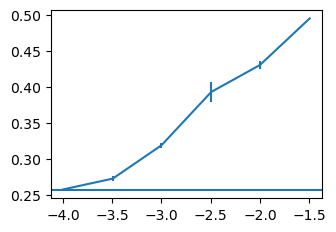

In [79]:
x_values = []
y_values = []
for data in dataset:
    eta = data['args'].eta * np.linalg.norm(data['a'][0])
    val = np.max(data['errors_with_new_readouts'])
    if x_values == []:
        x_values.append(np.log10(eta))
        y_values.append([val])
    else:
        duplicate = False
        for i, y in enumerate(x_values):
            if np.abs(np.log10(eta) - y) < 0.1:
                duplicate = True
                y_values[i].append(val)
                break
        if not duplicate:
            x_values.append(np.log10(eta))
            y_values.append([val])

y_vals_np = np.array(y_values)
x_val_np = np.array(x_values)
y_vals_np = y_vals_np[np.argsort(x_val_np)]
x_val_np = np.sort(x_val_np)

plt.figure()
plt.errorbar(x_val_np, y_vals_np.mean(1), y_vals_np.std(1) / np.sqrt(5))
_net = model.Model(data['args'])
stim = utils.GaborStimuli(data['args'], simple_mode=True)
plt.axhline(utils.fi_to_error(utils.get_mean_field_fi(_net, stim)))
plt.savefig('figures/raw/max_error_over_eta_1l.svg')

In [74]:
y_values

[[0.4958991792623706,
  0.49553996335190464,
  0.49300174924860274,
  0.49584434366870456,
  0.49558254988225914],
 [0.4225332739519231,
  0.3945084043007482,
  0.42645011167045155,
  0.3733789457586285,
  0.3478220015510298],
 [0.25690371212037166,
  0.25749806044098755,
  0.2573961882002187,
  0.2587338805859998,
  0.25633599959631326],
 [0.3236916717765178,
  0.3026670335206332,
  0.31878939644336135,
  0.3274828928807536,
  0.32143653691386664],
 [0.2697313688711126,
  0.2723013765192115,
  0.2660359713652338,
  0.2685034327381557,
  0.2856745490260575],
 [0.4378567341726801,
  0.42341251282294434,
  0.4495479237441531,
  0.4229242246277021,
  0.41837974248094134]]

## Covariance structure

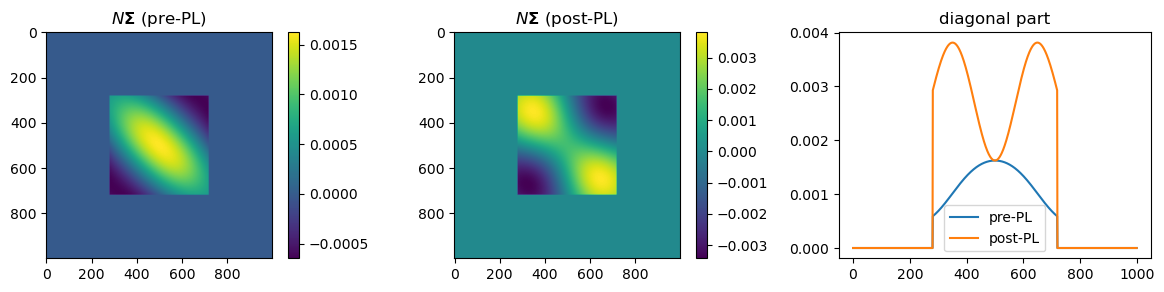

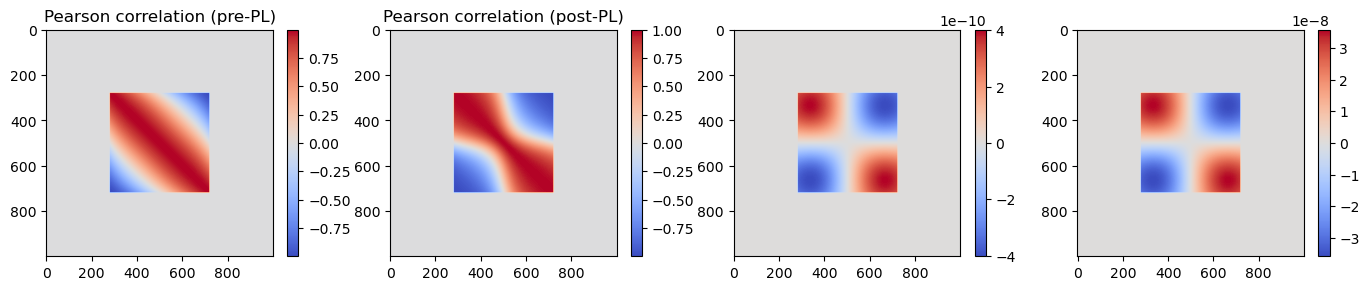

In [59]:

to_layer = 3
theory_ind = 23
file_name = 'Saved Results/theory_3L_sigs0P2'

theory_dict = pickle.load(open(file_name, 'rb'))
args = theory_dict['args']
args.sig_w = theory_dict['vary_values'][theory_ind]

stimuli = utils.GaborStimuli(args, simple_mode=True, verbose=False)
net0 = model.Model(args)
net1 = model.Model(args)

# Load MP changes to `net1`
utils.load_theory_from_file(net1, theory_dict, theory_ind)
F0 = utils.matrix_prod(utils.get_effective_weights(net0, stimuli.x0, full_mat=True)[0], num_mats=to_layer)
F1 = utils.matrix_prod(utils.get_effective_weights(net1, stimuli.x0, full_mat=True)[0], num_mats=to_layer)

covar = F0 @ F0.T * args.N
covar2 = F1 @ F1.T * args.N

covar_fig = plt.figure(figsize=(12, 3))
covar_fig.add_subplot(131)
plt.imshow(covar)
plt.colorbar(); plt.title('$N \mathbf{\Sigma}$ (pre-PL)')

covar_fig.add_subplot(132)
plt.imshow(covar2)
plt.colorbar(); plt.title('$N \mathbf{\Sigma}$ (post-PL)')

covar_fig.add_subplot(133)
plt.plot(np.diag(covar), label='pre-PL')
plt.plot(np.diag(covar2), label='post-PL')
plt.title('diagonal part'); plt.legend()
plt.tight_layout()

covar_fig = plt.figure(figsize=(17, 3))
covar_fig.add_subplot(141)
plt.imshow(utils.covar2corr(covar), cmap='coolwarm')
plt.colorbar(); plt.title('Pearson correlation (pre-PL)')

covar_fig.add_subplot(142)
plt.imshow(utils.covar2corr(covar2), cmap='coolwarm')
plt.colorbar(); plt.title('Pearson correlation (post-PL)')

covar_fig.add_subplot(143)
plt.imshow(F0 @ stimuli.x1.numpy().T @ (F0 @ stimuli.x1.numpy().T).T, cmap='coolwarm')
plt.colorbar()

covar_fig.add_subplot(144)
plt.imshow(F1 @ stimuli.x1.numpy().T @ (F1 @ stimuli.x1.numpy().T).T, cmap='coolwarm')
plt.colorbar()

In [45]:
stimuli.x1.shape

torch.Size([1, 1000])